
# Big Five Human vs AI Psychometric Fidelity Notebook

This Colab notebook runs a full **five-level evaluation framework** for Big Five questionnaire responses:

1. **Central tendency fidelity**
2. **Distribution fidelity**
3. **Reliability fidelity**
4. **Structural fidelity**
5. **Behavioral fidelity**

It is built for your two-file workflow:
- one **AI/model** file with a `model` column and the 50 Big Five item columns
- one **human** file with the same 50 item columns, plus optional quality flags such as `exclude_any`

The notebook:
- asks you to **upload both files**
- parses and validates the schema
- reverse-codes items using a data-driven key (with override support)
- scores the five traits
- runs the main tests at each level
- produces **publication-ready tables and figures**
- writes all outputs to an `outputs/` folder for download


In [1]:
# If you are in Google Colab, run this cell first.
# It installs the packages used in the notebook.
try:
    import google.colab  # noqa
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    !pip -q install factor_analyzer pingouin statsmodels openpyxl


In [2]:
import os
import io
import json
import math
import random
import warnings
from pathlib import Path

import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import wasserstein_distance, ks_2samp, energy_distance, entropy
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans
from factor_analyzer import FactorAnalyzer
import pingouin as pg

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

RNG = np.random.default_rng(42)
OUTDIR = Path("outputs")
DATA_DIR = Path("./data")
OUTDIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)



## 2) Load and validate the files


In [ ]:
# Default local files
human_data_path = DATA_DIR / "human_data_cleaned.csv"
llm_data_path = DATA_DIR / "big5_llm.csv"

if not human_data_path.exists():
    url = "https://huggingface.co/datasets/Anonymous0624/llm-psychometric-fidelity-audit/resolve/main/human_data_cleaned.csv"
    urllib.request.urlretrieve(url, human_data_path)
if not llm_data_path.exists():
    url = "https://huggingface.co/datasets/Anonymous0624/llm-psychometric-fidelity-audit/resolve/main/big5_llm.csv"
    urllib.request.urlretrieve(url, llm_data_path)

print("human_data_path:", human_data_path)
print("llm_data_path:", llm_data_path)

human_data_path: data/human_data_cleaned.csv
llm_data_path: data/big5_llm.csv


In [4]:

TRAIT_PREFIXES = {
    "Extraversion": "EXT",
    "Emotional_Stability": "EST",
    "Agreeableness": "AGR",
    "Conscientiousness": "CSN",
    "Openness": "OPN",
}
AI_TRAIT_PREFIXES = {
    "Extraversion": "EXT",
    "Emotional_Stability": "EST",
    "Agreeableness": "AGR",
    "Conscientiousness": "CSN",
    "Openness": "OPN",
}
HUMAN_TRAIT_PREFIXES = {
    "Extraversion": "EXT",
    "Emotional_Stability": "EST",
    "Agreeableness": "AGR",
    "Conscientiousness": "CSN",
    "Openness": "OPN",
}
ITEM_COLS = [f"{p}{i}" for p in TRAIT_PREFIXES.values() for i in range(1, 11)]


def load_csv_safely(path):
    try:
        return pd.read_csv(path)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="latin-1")

def build_column_rename_map(df, source_prefixes, target_prefixes):
    rename_map = {}
    lower_lookup = {str(c).lower(): c for c in df.columns}
    for trait, src_prefix in source_prefixes.items():
        tgt_prefix = target_prefixes[trait]
        for i in range(1, 11):
            src = f"{src_prefix}{i}"
            tgt = f"{tgt_prefix}{i}"
            if src in df.columns:
                rename_map[src] = tgt
            elif src.lower() in lower_lookup:
                rename_map[lower_lookup[src.lower()]] = tgt
    return rename_map


ai_df = load_csv_safely(llm_data_path)
human_df = load_csv_safely(human_data_path)

# Normalize both datasets to canonical ITEM_COLS
ai_df = ai_df.rename(columns=build_column_rename_map(ai_df, AI_TRAIT_PREFIXES, TRAIT_PREFIXES))
human_df = human_df.rename(columns=build_column_rename_map(human_df, HUMAN_TRAIT_PREFIXES, TRAIT_PREFIXES))

missing_ai = [c for c in ITEM_COLS + ["model"] if c not in ai_df.columns]
missing_human = [c for c in ITEM_COLS if c not in human_df.columns]

print("AI path:", llm_data_path)
print("Human path:", human_data_path)
print("AI shape:", ai_df.shape)
print("Human shape:", human_df.shape)

if missing_ai:
    raise ValueError(f"AI file is missing required columns: {missing_ai}")
if missing_human:
    raise ValueError(f"Human file is missing required item columns: {missing_human}")

display(ai_df.head(5))
display(human_df.head(5))


AI path: data/big5_llm.csv
Human path: data/human_data_cleaned.csv
AI shape: (80000, 52)
Human shape: (500703, 136)


,model,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,EST1,EST2,EST3,EST4,EST5,EST6,EST7,EST8,EST9,EST10,AGR1,AGR2,AGR3,AGR4,AGR5,AGR6,AGR7,AGR8,AGR9,AGR10,CSN1,CSN2,CSN3,CSN4,CSN5,CSN6,CSN7,CSN8,CSN9,CSN10,OPN1,OPN2,OPN3,OPN4,OPN5,OPN6,OPN7,OPN8,OPN9,OPN10,_source_file
0,claude-haiku-4.5,3,3,4,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,2,4,1,4,2,4,2,4,4,4,4,2,4,2,4,2,4,1,4,4,4,2,4,2,4,2,4,3,4,4,big_five_claude-haiku-4.5_13.csv
1,claude-haiku-4.5,3,3,4,3,3,3,3,3,3,3,3,3,3,3,2,2,2,2,2,2,2,4,1,4,2,4,2,4,4,3,4,2,4,2,4,2,4,1,4,4,4,2,4,2,4,2,4,3,4,4,big_five_claude-haiku-4.5_13.csv
2,claude-haiku-4.5,3,3,4,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,2,4,1,4,2,4,2,4,4,4,4,2,4,2,4,2,4,1,4,4,4,2,4,2,4,2,4,3,4,4,big_five_claude-haiku-4.5_13.csv
3,claude-haiku-4.5,3,3,4,3,3,3,3,3,3,2,3,3,3,3,2,2,2,2,2,2,2,4,1,4,2,4,2,4,4,3,4,2,4,2,4,2,4,1,4,4,4,2,4,2,4,2,4,3,4,4,big_five_claude-haiku-4.5_13.csv
4,claude-haiku-4.5,3,4,3,4,2,4,2,4,2,4,3,3,4,3,2,3,3,3,3,3,2,4,1,4,2,4,2,3,4,3,4,3,4,2,4,3,4,2,4,4,4,2,4,2,4,2,4,3,4,4,big_five_claude-haiku-4.5_13.csv


,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,EST1,EST2,EST3,EST4,EST5,EST6,EST7,EST8,EST9,EST10,AGR1,AGR2,AGR3,AGR4,AGR5,AGR6,AGR7,AGR8,AGR9,AGR10,CSN1,CSN2,CSN3,CSN4,CSN5,CSN6,CSN7,CSN8,CSN9,CSN10,OPN1,OPN2,OPN3,OPN4,OPN5,OPN6,OPN7,OPN8,OPN9,OPN10,EXT1_E,EXT2_E,EXT3_E,EXT4_E,EXT5_E,EXT6_E,EXT7_E,EXT8_E,EXT9_E,EXT10_E,EST1_E,EST2_E,EST3_E,EST4_E,EST5_E,EST6_E,EST7_E,EST8_E,EST9_E,EST10_E,AGR1_E,AGR2_E,AGR3_E,AGR4_E,AGR5_E,AGR6_E,AGR7_E,AGR8_E,AGR9_E,AGR10_E,CSN1_E,CSN2_E,CSN3_E,CSN4_E,CSN5_E,CSN6_E,CSN7_E,CSN8_E,CSN9_E,CSN10_E,OPN1_E,OPN2_E,OPN3_E,OPN4_E,OPN5_E,OPN6_E,OPN7_E,OPN8_E,OPN9_E,OPN10_E,dateload,screenw,screenh,introelapse,testelapse,endelapse,IPC,country,lat_appx_lots_of_err,long_appx_lots_of_err,flag_ipc_duplicate,flag_missing_items,flag_item_out_of_range,mean_item_time_seconds,flag_speeding,item_unique_count,item_variance,flag_straightlining,max_longstring,flag_longstring,mahalanobis_d2,mahalanobis_cutoff,flag_mahalanobis,screenw_iqr_low,screenw_iqr_high,flag_screenw_outlier,flag_screenw_nonpositive,screenh_iqr_low,screenh_iqr_high,flag_screenh_outlier,flag_screenh_nonpositive,testelapse_iqr_low,testelapse_iqr_high,flag_testelapse_outlier,flag_testelapse_nonpositive,exclude_any
0,4.0,1.0,5.0,2.0,5.0,1.0,5.0,2.0,4.0,1.0,1.0,4.0,4.0,2.0,2.0,2.0,2.0,2.0,3.0,2.0,2.0,5.0,2.0,4.0,2.0,3.0,2.0,4.0,3.0,4.0,3.0,4.0,3.0,2.0,2.0,4.0,4.0,2.0,4.0,4.0,5.0,1.0,4.0,1.0,4.0,1.0,5.0,3.0,4.0,5.0,9419.0,5491.0,3959.0,4821.0,5611.0,2756.0,2388.0,2113.0,5900.0,4110.0,6135.0,4150.0,5739.0,6364.0,3663.0,5070.0,5709.0,4285.0,2587.0,3997.0,4750.0,5475.0,11641.0,3115.0,3207.0,3260.0,10235.0,5897.0,1758.0,3081.0,6602.0,5457.0,1569.0,2129.0,3762.0,4420.0,9382.0,5286.0,4983.0,6339.0,3146.0,4067.0,2959.0,3411.0,2170.0,4920.0,4436.0,3116.0,2992.0,4354.0,2016-03-03 02:01:01,768.0,1024.0,9.0,234.0,6,1,GB,51.5448,0.1991,False,False,False,4.64372,False,5,1.755102,False,3,False,25.739793,86.660815,False,-1125.0,2979.0,False,False,450.0,1170.0,False,False,-42.0,526.0,False,False,False
1,3.0,5.0,3.0,4.0,3.0,3.0,2.0,5.0,1.0,5.0,2.0,3.0,4.0,1.0,3.0,1.0,2.0,1.0,3.0,1.0,1.0,4.0,1.0,5.0,1.0,5.0,3.0,4.0,5.0,3.0,3.0,2.0,5.0,3.0,3.0,1.0,3.0,3.0,5.0,3.0,1.0,2.0,4.0,2.0,3.0,1.0,4.0,2.0,5.0,3.0,7235.0,3598.0,3315.0,2564.0,2976.0,3050.0,4787.0,3228.0,3465.0,3309.0,9036.0,2406.0,3484.0,3359.0,3061.0,2539.0,4226.0,2962.0,1799.0,1607.0,2158.0,2090.0,2143.0,2807.0,3422.0,5324.0,4494.0,3627.0,1850.0,1747.0,5163.0,5240.0,7208.0,2783.0,4103.0,3431.0,3347.0,2399.0,3360.0,5595.0,2624.0,4985.0,1684.0,3026.0,4742.0,3336.0,2718.0,3374.0,3096.0,3019.0,2016-03-03 02:01:20,1360.0,768.0,12.0,179.0,11,1,MY,3.1698,101.706,False,False,False,3.53802,False,5,1.887755,False,4,False,50.402682,86.660815,False,-1125.0,2979.0,False,False,450.0,1170.0,False,False,-42.0,526.0,False,False,False
2,2.0,3.0,4.0,4.0,3.0,2.0,1.0,3.0,2.0,5.0,4.0,4.0,4.0,2.0,2.0,2.0,2.0,2.0,1.0,3.0,1.0,4.0,1.0,4.0,2.0,4.0,1.0,4.0,4.0,3.0,4.0,2.0,2.0,2.0,3.0,3.0,4.0,2.0,4.0,2.0,5.0,1.0,2.0,1.0,4.0,2.0,5.0,3.0,4.0,4.0,4657.0,3549.0,2543.0,3335.0,5847.0,2540.0,4922.0,3142.0,14621.0,2191.0,5128.0,3675.0,3442.0,4546.0,8275.0,2185.0,2164.0,1175.0,3813.0,1593.0,1089.0,2203.0,3386.0,1464.0,2562.0,1493.0,3067.0,13719.0,3892.0,4100.0,4286.0,4775.0,2713.0,2813.0,4237.0,6308.0,2690.0,1516.0,2379.0,2983.0,1930.0,1470.0,1644.0,1683.0,2229.0,8114.0,2043.0,6295.0,1585.0,2529.0,2016-03-03 02:01:56,1366.0,768.0,3.0,186.0,7,1,GB,54.9119,-1.3833,False,False,False,3.69080,False,5,1.443265,False,2,False,39.129625,86.660815,False,-1125.0,2979.0,False,False,450.0,1170.0,False,False,-42.0,526.0,False,False,False
3,3.0,3.0,4.0,2.0,4.0,2.0,2.0,3.0,3.0,4.0,3.0,4.0,3.0,2.0,2.0,1.0,2.0,1.0,2.0,2.0,2.0,3.0,1.0,4.0,2.0,3.0,2.0,3.0,4.0,4.0,3.0,2.0,4.0,1.0,3.0,2.0,4.0,3.0,4.0,3.0,5.0,1.0,5.0,1.0,3.0,1.0,5.0,4.0,5.0,2.0,4834.0,5064.0,1160.0,2664.0,6711.0,3344.0,2512.0,6264.0,6992.0,4592.0,2808.0,1776.0,3280.0,4520.0,2640.0,5408.0,3647.0,3183.0,1575.0,672.0,6375.0,4727.0,3775.0,1647.0,1233.0,8694.0,2904.0,2152.0,2856.0,2848.0,4288.0,4360.0,7328.


## 3) Cleaning and scoring setup

This notebook uses a transparent, editable scoring pipeline.

### Default behavior
- Human file:
  - if `exclude_any` exists, rows with `exclude_any == True` are removed
  - only the 50 item columns are used for scoring
- AI file:
  - keeps the `model` column and 50 item columns
- All item responses are expected to be on a **1–5 Likert scale**

### Reverse coding
The notebook will infer reverse-coded items from the human data using corrected item-total correlation signs **within each trait block**.

That is practical for this dataset, but if you have an official key, you can override it in the next cell.


In [5]:

# ---------------------------
# Editable configuration
# ---------------------------

LIKERT_MIN = 1
LIKERT_MAX = 5

# To keep permutation tests computationally manageable,
# optionally downsample each group for the distribution tests.
MAX_N_PER_GROUP_FOR_DIST_TESTS = 10000

# Permutation count:
# 1000 = good starting point
# 5000 = stronger paper setting
N_PERM = 5000

# Set to True to save all tables as CSV / Excel and all figures as PNG.
SAVE_OUTPUTS = True

# Optional manual override for reverse-coded items:
# Example:
# MANUAL_REVERSE_KEY = {
#     "Extraversion": ["EXT2", "EXT4", ...],
#     ...
# }
MANUAL_REVERSE_KEY = {
    "Extraversion":        ["EXT2", "EXT4", "EXT6", "EXT8", "EXT10"],
    "Emotional_Stability": ["EST1", "EST3", "EST5", "EST6", "EST7", "EST8", "EST9", "EST10"],
    "Agreeableness":       ["AGR1", "AGR3", "AGR5", "AGR7"],
    "Conscientiousness":   ["CSN2", "CSN4", "CSN6", "CSN8"],
    "Openness":            ["OPN2", "OPN4", "OPN6"],
}


# Additional inferential settings for Levels 3 and 4.
# These are deliberately separate from Level 2 because reliability and structural
# resampling can be much more computationally expensive.
MAX_N_PER_GROUP_FOR_L3L4_INFERENCE = 5000
N_BOOT_L3 = 500
N_PERM_L3 = 1000
N_BOOT_L4 = 500
N_PERM_L4 = 1000


# Plots
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'savefig.facecolor': 'white',
    'axes.edgecolor':    'black',
    'axes.labelcolor':   'black',
    'axes.titlecolor':   'black',
    'xtick.color':       'black',
    'ytick.color':       'black',
    'text.color':        'black',
    'grid.color':        'black',
    'lines.color':       'black',
    # 'grid.alpha':        0.3,
    'legend.facecolor':  'white',
    'legend.edgecolor':  'black',
    'legend.labelcolor': 'black',
})


In [6]:

def keep_clean_humans(df):
    out = df.copy()
    if "exclude_any" in out.columns:
        out = out.loc[~out["exclude_any"].fillna(False)].copy()
    return out

def coerce_likert(df, item_cols):
    out = df.copy()
    for c in item_cols:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

human = keep_clean_humans(human_df)
human = coerce_likert(human, ITEM_COLS)
ai = coerce_likert(ai_df, ITEM_COLS)

# Drop rows with missing item values
human = human.dropna(subset=ITEM_COLS).reset_index(drop=True)
ai = ai.dropna(subset=ITEM_COLS + ["model"]).reset_index(drop=True)

# Basic range check
def range_violations(df, item_cols, lo=1, hi=5):
    mask = pd.DataFrame({c: ~df[c].between(lo, hi) for c in item_cols})
    return mask.any(axis=1).sum()

print("Human clean shape:", human.shape)
print("AI clean shape:", ai.shape)
print("Human out-of-range rows:", range_violations(human, ITEM_COLS, LIKERT_MIN, LIKERT_MAX))
print("AI out-of-range rows:", range_violations(ai, ITEM_COLS, LIKERT_MIN, LIKERT_MAX))
print("Models:", ai["model"].nunique(), sorted(ai["model"].unique())[:10])


Human clean shape: (500703, 136)
AI clean shape: (80000, 52)
Human out-of-range rows: 0
AI out-of-range rows: 0
Models: 8 ['claude-haiku-4.5', 'claude-sonnet-4.6', 'deepseek-v3.2', 'gemini-3-flash-preview', 'gemini-3.1-flash-lite-preview', 'gpt-5.4', 'gpt-5.4-mini', 'gpt-5.4-nano']


In [7]:

def cronbach_alpha_manual(df_items):
    item_var = df_items.var(axis=0, ddof=1)
    total = df_items.sum(axis=1)
    total_var = total.var(ddof=1)
    n_items = df_items.shape[1]
    if total_var == 0:
        return np.nan
    return (n_items / (n_items - 1)) * (1 - item_var.sum() / total_var)

def corrected_item_total_corr(df_items):
    out = {}
    for c in df_items.columns:
        rest = df_items.drop(columns=[c]).sum(axis=1)
        if df_items[c].std(ddof=1) == 0 or rest.std(ddof=1) == 0:
            out[c] = np.nan
        else:
            out[c] = np.corrcoef(df_items[c], rest)[0, 1]
    return pd.Series(out)

def infer_reverse_key_from_humans(human_df):
    reverse_key = {}
    diagnostics = []
    for trait, prefix in TRAIT_PREFIXES.items():
        cols = [f"{prefix}{i}" for i in range(1, 11)]
        items = human_df[cols].copy()
        corr = corrected_item_total_corr(items)
        reverse_cols = corr[corr < 0].index.tolist()
        reverse_key[trait] = reverse_cols
        for c, v in corr.items():
            diagnostics.append({"trait": trait, "item": c, "corrected_item_total_r": v, "inferred_reverse": c in reverse_cols})
    return reverse_key, pd.DataFrame(diagnostics)

def reverse_code(df, reverse_cols, lo=1, hi=5):
    out = df.copy()
    for c in reverse_cols:
        out[c] = lo + hi - out[c]
    return out

def score_traits(df):
    out = df.copy()
    for trait, prefix in TRAIT_PREFIXES.items():
        cols = [f"{prefix}{i}" for i in range(1, 11)]
        out[trait] = out[cols].mean(axis=1)
    return out

if MANUAL_REVERSE_KEY is None:
    reverse_key, reverse_diagnostics = infer_reverse_key_from_humans(human)
else:
    reverse_key = MANUAL_REVERSE_KEY
    reverse_diagnostics = pd.DataFrame([
        {"trait": trait, "item": item, "corrected_item_total_r": np.nan, "inferred_reverse": True}
        for trait, items in reverse_key.items() for item in items
    ])

reverse_cols_flat = [item for items in reverse_key.values() for item in items]

print("Inferred / chosen reverse-coded items:")
for trait, items in reverse_key.items():
    print(f"{trait}: {items}")

display(reverse_diagnostics.head(20))

human_scored = score_traits(reverse_code(human, reverse_cols_flat, LIKERT_MIN, LIKERT_MAX))
ai_scored = score_traits(reverse_code(ai, reverse_cols_flat, LIKERT_MIN, LIKERT_MAX))


Inferred / chosen reverse-coded items:
Extraversion: ['EXT2', 'EXT4', 'EXT6', 'EXT8', 'EXT10']
Emotional_Stability: ['EST1', 'EST3', 'EST5', 'EST6', 'EST7', 'EST8', 'EST9', 'EST10']
Agreeableness: ['AGR1', 'AGR3', 'AGR5', 'AGR7']
Conscientiousness: ['CSN2', 'CSN4', 'CSN6', 'CSN8']
Openness: ['OPN2', 'OPN4', 'OPN6']


,trait,item,corrected_item_total_r,inferred_reverse
0,Extraversion,EXT2,NaN,True
1,Extraversion,EXT4,NaN,True
2,Extraversion,EXT6,NaN,True
3,Extraversion,EXT8,NaN,True
4,Extraversion,EXT10,NaN,True
5,Emotional_Stability,EST1,NaN,True
6,Emotional_Stability,EST3,NaN,True
7,Emotional_Stability,EST5,NaN,True
8,Emotional_Stability,EST6,NaN,True
9,Emotional_Stability,EST7,NaN,True



## 4) Helper functions for tests and figure/table export


In [8]:

def hedges_g(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    nx, ny = len(x), len(y)
    sx, sy = x.std(ddof=1), y.std(ddof=1)
    sp = np.sqrt(((nx-1)*sx**2 + (ny-1)*sy**2) / (nx+ny-2))
    if sp == 0:
        return np.nan
    d = (x.mean() - y.mean()) / sp
    correction = 1 - (3 / (4*(nx+ny) - 9))
    return d * correction

def welch_ci(x, y, alpha=0.05):
    cm = CompareMeans(DescrStatsW(x), DescrStatsW(y))
    low, high = cm.tconfint_diff(usevar='unequal', alpha=alpha)
    return low, high

def permutation_pvalue_distance(x, y, distance_func, n_perm=1000, seed=42):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    observed = distance_func(x, y)
    pooled = np.concatenate([x, y])
    nx = len(x)
    count = 0
    for _ in range(n_perm):
        rng.shuffle(pooled)
        xp = pooled[:nx]
        yp = pooled[nx:]
        d = distance_func(xp, yp)
        if d >= observed:
            count += 1
    p = (count + 1) / (n_perm + 1)
    return observed, p

def brown_forsythe(x, y):
    return stats.levene(x, y, center='median')

def cramers_v_from_table(tbl):
    chi2 = stats.chi2_contingency(tbl)[0]
    n = tbl.to_numpy().sum()
    r, k = tbl.shape
    denom = max(1, min(k-1, r-1))
    return np.sqrt((chi2 / n) / denom)

def shannon_entropy_from_counts(counts):
    probs = np.asarray(counts, dtype=float)
    probs = probs / probs.sum()
    return entropy(probs, base=2)

def save_df(df, name):
    if SAVE_OUTPUTS:
        df.to_csv(OUTDIR / f"{name}.csv", index=False)

def save_fig(fig, name):
    if SAVE_OUTPUTS:
        fig.savefig(OUTDIR / f"{name}.png", dpi=200, bbox_inches="tight")

def standardize_trait_order(df):
    cols = [c for c in TRAIT_PREFIXES if c in df.columns]
    return df[cols]



def maybe_downsample_df(df, max_n, rng):
    if len(df) <= max_n:
        return df.reset_index(drop=True).copy()
    idx = rng.choice(len(df), size=max_n, replace=False)
    return df.iloc[idx].reset_index(drop=True).copy()

def bootstrap_ci_rows(df_items, stat_func, n_boot=300, seed=42):
    rng = np.random.default_rng(seed)
    vals = []
    n = len(df_items)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        sample = df_items.iloc[idx].reset_index(drop=True)
        try:
            vals.append(float(stat_func(sample)))
        except Exception:
            vals.append(np.nan)
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan, np.nan, np.array([])
    return np.quantile(vals, 0.025), np.quantile(vals, 0.975), vals

def bootstrap_diff_ci_rows(df_a, df_b, stat_func, n_boot=300, seed=42):
    rng = np.random.default_rng(seed)
    vals = []
    na = len(df_a)
    nb = len(df_b)
    for _ in range(n_boot):
        ia = rng.integers(0, na, size=na)
        ib = rng.integers(0, nb, size=nb)
        sa = df_a.iloc[ia].reset_index(drop=True)
        sb = df_b.iloc[ib].reset_index(drop=True)
        try:
            vals.append(float(stat_func(sb) - stat_func(sa)))
        except Exception:
            vals.append(np.nan)
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan, np.nan, np.array([])
    return np.quantile(vals, 0.025), np.quantile(vals, 0.975), vals

def permutation_pvalue_rows(df_a, df_b, stat_func, n_perm=300, seed=42, alternative="two-sided"):
    rng = np.random.default_rng(seed)
    observed_a = float(stat_func(df_a))
    observed_b = float(stat_func(df_b))
    observed_diff = observed_b - observed_a
    pooled = pd.concat([df_a, df_b], axis=0, ignore_index=True)
    na = len(df_a)
    perm_diffs = []
    for _ in range(n_perm):
        idx = rng.permutation(len(pooled))
        a_idx = idx[:na]
        b_idx = idx[na:]
        sa = pooled.iloc[a_idx].reset_index(drop=True)
        sb = pooled.iloc[b_idx].reset_index(drop=True)
        try:
            d = float(stat_func(sb) - stat_func(sa))
        except Exception:
            d = np.nan
        perm_diffs.append(d)
    perm_diffs = np.asarray(perm_diffs, dtype=float)
    perm_diffs = perm_diffs[np.isfinite(perm_diffs)]
    if len(perm_diffs) == 0:
        return observed_diff, np.nan
    if alternative == "greater":
        p = (np.sum(perm_diffs >= observed_diff) + 1) / (len(perm_diffs) + 1)
    elif alternative == "less":
        p = (np.sum(perm_diffs <= observed_diff) + 1) / (len(perm_diffs) + 1)
    else:
        p = (np.sum(np.abs(perm_diffs) >= abs(observed_diff)) + 1) / (len(perm_diffs) + 1)
    return observed_diff, p



# Level 1 — Central tendency fidelity

**Question:** Does each model match humans on average Big Five trait scores?

### Tests used
- Welch's t-test per model × trait
- Hedges' g
- 95% CI for mean difference
- One-way ANOVA across models for each trait
- Welch ANOVA across models for each trait


In [9]:

central_rows = []

for model_name, model_df in ai_scored.groupby("model"):
    for trait in TRAIT_PREFIXES:
        hx = human_scored[trait].to_numpy()
        ax = model_df[trait].to_numpy()

        t_res = stats.ttest_ind(hx, ax, equal_var=False)
        ci_low, ci_high = welch_ci(hx, ax)
        central_rows.append({
            "model": model_name,
            "trait": trait,
            "human_n": len(hx),
            "ai_n": len(ax),
            "human_mean": np.mean(hx),
            "ai_mean": np.mean(ax),
            "human_sd": np.std(hx, ddof=1),
            "ai_sd": np.std(ax, ddof=1),
            "mean_diff_human_minus_ai": np.mean(hx) - np.mean(ax),
            "welch_t": t_res.statistic,
            "p_value": t_res.pvalue,
            "hedges_g": hedges_g(hx, ax),
            "ci_low": ci_low,
            "ci_high": ci_high,
        })

central_table = pd.DataFrame(central_rows)
central_table["p_fdr"] = multipletests(central_table["p_value"], method="fdr_bh")[1]
central_table = central_table.sort_values(["trait", "model"]).reset_index(drop=True)
save_df(central_table, "level1_central_tendency_model_vs_human")
display(central_table.head(15))


,model,trait,human_n,ai_n,human_mean,ai_mean,human_sd,ai_sd,mean_diff_human_minus_ai,welch_t,p_value,hedges_g,ci_low,ci_high,p_fdr
0,claude-haiku-4.5,Agreeableness,500703,10000,3.785685,4.04422,0.722105,0.098405,-0.258535,-182.367317,0.0,-0.361519,-0.261314,-0.255756,0.0
1,claude-sonnet-4.6,Agreeableness,500703,10000,3.785685,4.07427,0.722105,0.067152,-0.288585,-236.231955,0.0,-0.403579,-0.290979,-0.286191,0.0
2,deepseek-v3.2,Agreeableness,500703,10000,3.785685,4.64003,0.722105,0.272888,-0.854345,-293.241351,0.0,-1.193184,-0.860056,-0.848634,0.0
3,gemini-3-flash-preview,Agreeableness,500703,10000,3.785685,4.40799,0.722105,0.084249,-0.622305,-470.257980,0.0,-0.870236,-0.624899,-0.619711,0.0
4,gemini-3.1-flash-lite-preview,Agreeableness,500703,10000,3.785685,4.19018,0.722105,0.199829,-0.404495,-180.273682,0.0,-0.565294,-0.408893,-0.400097,0.0
5,gpt-5.4,Agreeableness,500703,10000,3.785685,4.69615,0.722105,0.126340,-0.910465,-560.609022,0.0,-1.272985,-0.913648,-0.907282,0.0
6,gpt-5.4-mini,Agreeableness,500703,10000,3.785685,4.15025,0.722105,0.168038,-0.364565,-185.436671,0.0,-0.509604,-0.368419,-0.360712,0.0
7,gpt-5.4-nano,Agreeableness,500703,10000,3.785685,4.04404,0.722105,0.086552,-0.258355,-193.075062,0.0,-0.361283,-0.260978,-0.255732,0.0
8,claude-haiku-4.5,Conscientiousness,500703,10000,3.349079,4.01458,0.733726,0.208365,-0.665501,-285.942498,0.0,-0.915290,-0.670063,-0.660939,0.0
9,claude-sonnet-4.6,Conscientiousness,500703,10000,3.349079,3.54272,0.733726,0.077328,-0.193641,-149.702863,0.0,-0.266507,-0.196177,-0.191106,0.0


In [10]:
anova_rows = []
for trait in TRAIT_PREFIXES:
    groups = [grp[trait].to_numpy() for _, grp in ai_scored.groupby("model")]
    labels = [name for name, _ in ai_scored.groupby("model")]

    f_stat, p_val = stats.f_oneway(*groups)
    long_df = ai_scored[["model", trait]].rename(columns={trait: "score"})
    welch = pg.welch_anova(data=long_df, dv="score", between="model")
    eta2 = pg.anova(data=long_df, dv="score", between="model", detailed=True)["np2"].iloc[0]

    anova_rows.append({
        "trait": trait,
        "anova_F": f_stat,
        "anova_p": p_val,
        "welch_F": welch["F"].iloc[0],
        "welch_p": welch["p_unc"].iloc[0],
        "partial_eta_squared": eta2,
    })

anova_table = pd.DataFrame(anova_rows)
save_df(anova_table, "level1_central_tendency_across_models")
display(anova_table)

,trait,anova_F,anova_p,welch_F,welch_p,partial_eta_squared
0,Extraversion,7189.504976,0.0,12107.486027,0.0,0.386181
1,Emotional_Stability,5681.229882,0.0,22634.007926,0.0,0.332068
2,Agreeableness,30353.828955,0.0,47801.938624,0.0,0.726494
3,Conscientiousness,14848.477219,0.0,104202.657475,0.0,0.565099
4,Openness,30686.478920,0.0,64977.271703,0.0,0.728654


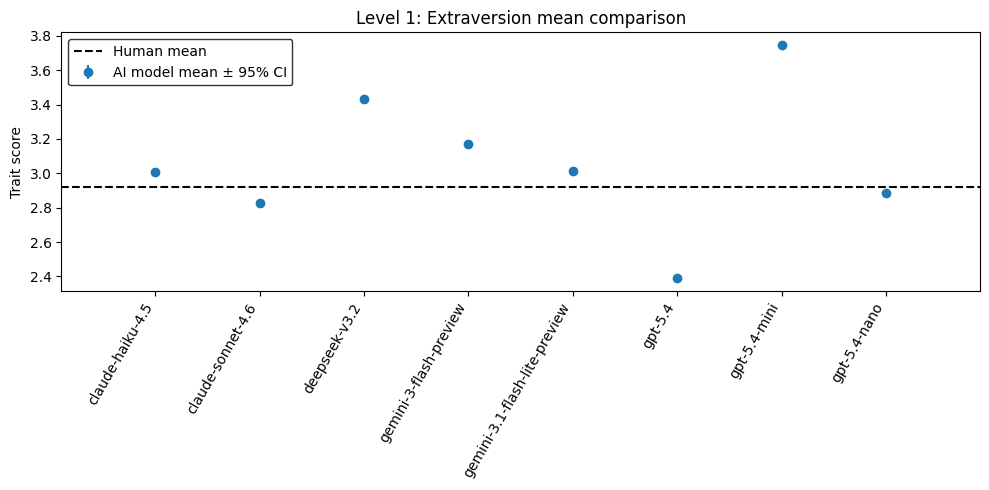

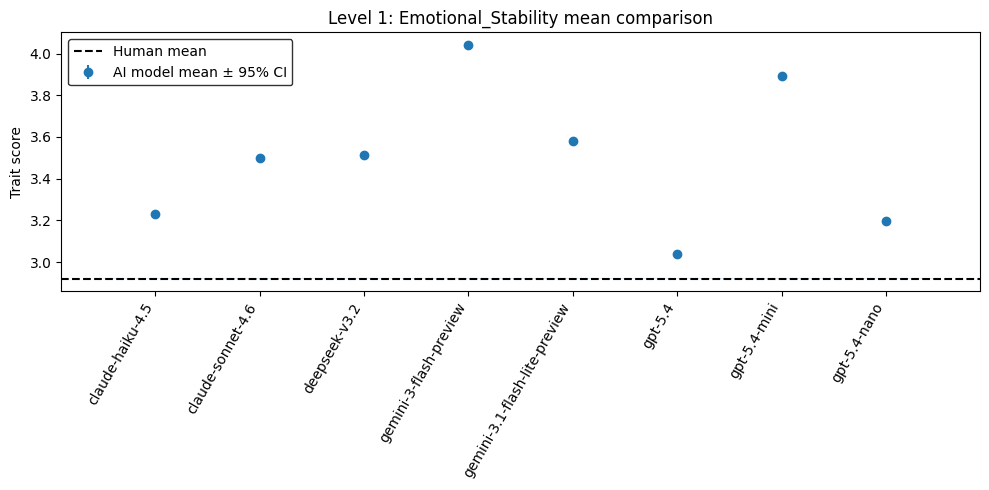

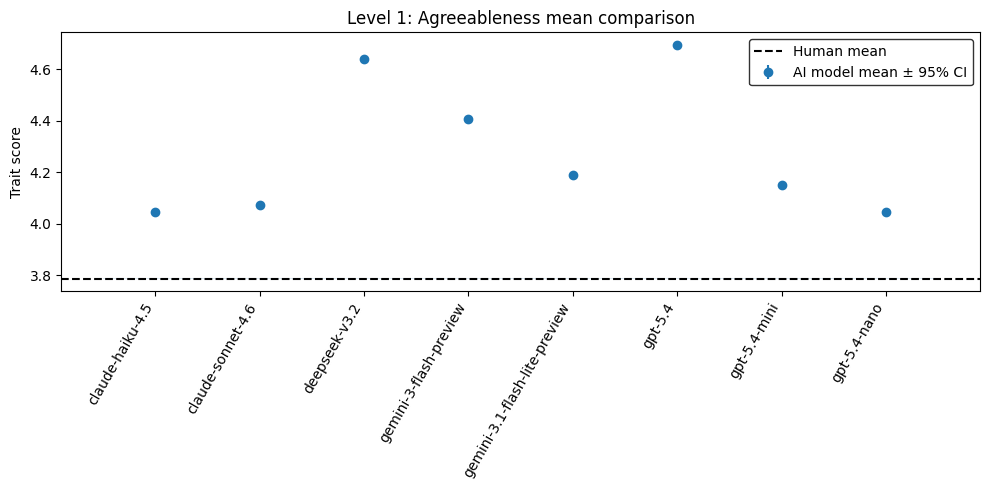

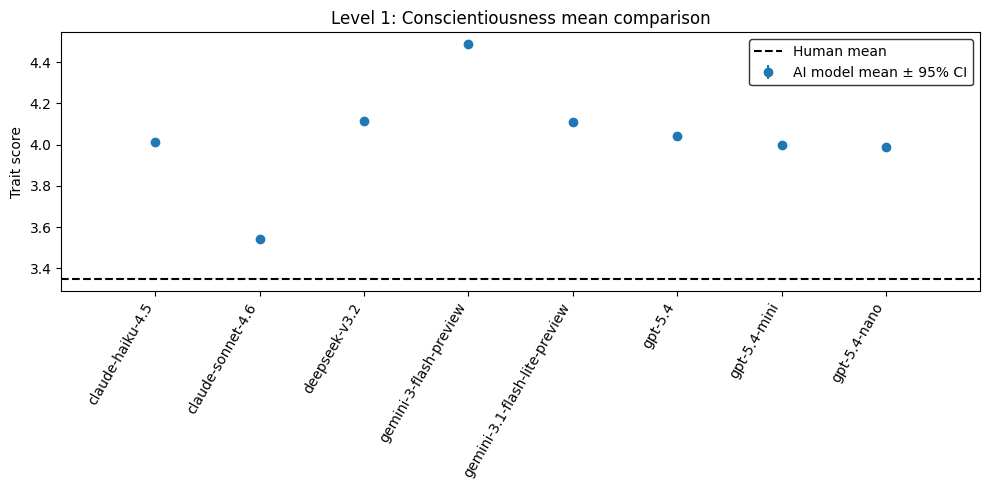

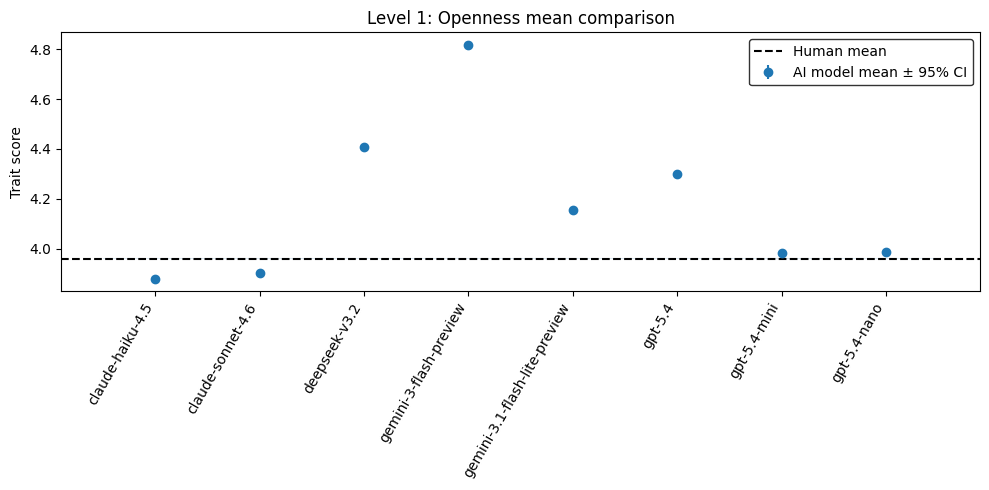

In [11]:

# Figure: human vs model means with 95% CI
for trait in TRAIT_PREFIXES:
    fig, ax = plt.subplots(figsize=(10, 5))
    sub = central_table.loc[central_table["trait"] == trait].copy()
    x = np.arange(len(sub))
    ax.errorbar(
        x,
        sub["ai_mean"],
        yerr=1.96 * sub["ai_sd"] / np.sqrt(sub["ai_n"]),
        fmt='o',
        label="AI model mean ± 95% CI"
    )
    human_mean = sub["human_mean"].iloc[0]
    human_ci = 1.96 * sub["human_sd"].iloc[0] / np.sqrt(sub["human_n"].iloc[0])
    ax.axhline(human_mean, linestyle='--', label="Human mean")
    ax.fill_between([-0.5, len(sub)-0.5], human_mean-human_ci, human_mean+human_ci, alpha=0.15)
    ax.set_xticks(x)
    ax.set_xticklabels(sub["model"], rotation=60, ha="right")
    ax.set_title(f"Level 1: {trait} mean comparison")
    ax.set_ylabel("Trait score")
    ax.legend()
    plt.tight_layout()
    save_fig(fig, f"level1_{trait}_mean_comparison")
    plt.show()



# Level 2 — Distribution fidelity

**Question:** Even if means are similar, do the full distributions match?

### Tests used
- Wasserstein distance
- Energy distance
- permutation p-value for Wasserstein
- Kolmogorov–Smirnov test
- Brown–Forsythe variance test
- skewness and kurtosis differences


In [12]:

def maybe_downsample(x, max_n, rng):
    x = np.asarray(x)
    if len(x) <= max_n:
        return x
    idx = rng.choice(len(x), size=max_n, replace=False)
    return x[idx]

dist_rows = []
rng = np.random.default_rng(42)

for model_name, model_df in ai_scored.groupby("model"):
    for trait in TRAIT_PREFIXES:
        hx = human_scored[trait].to_numpy()
        ax = model_df[trait].to_numpy()

        hx_s = maybe_downsample(hx, MAX_N_PER_GROUP_FOR_DIST_TESTS, rng)
        ax_s = maybe_downsample(ax, MAX_N_PER_GROUP_FOR_DIST_TESTS, rng)

        w_obs, w_p = permutation_pvalue_distance(hx_s, ax_s, wasserstein_distance, n_perm=N_PERM, seed=42)
        e_obs = energy_distance(hx_s, ax_s)
        ks = ks_2samp(hx_s, ax_s, alternative="two-sided", method="asymp")
        bf = brown_forsythe(hx_s, ax_s)

        dist_rows.append({
            "model": model_name,
            "trait": trait,
            "human_n_used": len(hx_s),
            "ai_n_used": len(ax_s),
            "wasserstein": w_obs,
            "wasserstein_perm_p": w_p,
            "energy_distance": e_obs,
            "ks_stat": ks.statistic,
            "ks_p": ks.pvalue,
            "brown_forsythe_stat": bf.statistic,
            "brown_forsythe_p": bf.pvalue,
            "human_skew": stats.skew(hx_s, bias=False),
            "ai_skew": stats.skew(ax_s, bias=False),
            "human_kurtosis": stats.kurtosis(hx_s, fisher=True, bias=False),
            "ai_kurtosis": stats.kurtosis(ax_s, fisher=True, bias=False),
        })

dist_table = pd.DataFrame(dist_rows)
dist_table["wasserstein_perm_p_fdr"] = multipletests(dist_table["wasserstein_perm_p"], method="fdr_bh")[1]
dist_table["ks_p_fdr"] = multipletests(dist_table["ks_p"], method="fdr_bh")[1]
dist_table["brown_forsythe_p_fdr"] = multipletests(dist_table["brown_forsythe_p"], method="fdr_bh")[1]
save_df(dist_table, "level2_distribution_fidelity")
display(dist_table.head(15))


,model,trait,human_n_used,ai_n_used,wasserstein,wasserstein_perm_p,energy_distance,ks_stat,ks_p,brown_forsythe_stat,brown_forsythe_p,human_skew,ai_skew,human_kurtosis,ai_kurtosis,wasserstein_perm_p_fdr,ks_p_fdr,brown_forsythe_p_fdr
0,claude-haiku-4.5,Extraversion,10000,10000,0.67393,0.0002,0.606077,0.4609,0.0,14429.070574,0.000000e+00,0.084179,-3.429210,-0.739813,10.600316,0.0002,0.0,0.000000e+00
1,claude-haiku-4.5,Emotional_Stability,10000,10000,0.50913,0.0002,0.533993,0.5069,0.0,6539.477315,0.000000e+00,0.099006,0.859860,-0.583625,-0.698600,0.0002,0.0,0.000000e+00
2,claude-haiku-4.5,Agreeableness,10000,10000,0.54095,0.0002,0.551678,0.4991,0.0,11746.059978,0.000000e+00,-0.697662,-6.569801,0.338977,66.192002,0.0002,0.0,0.000000e+00
3,claude-haiku-4.5,Conscientiousness,10000,10000,0.77582,0.0002,0.815728,0.6492,0.0,11636.129291,0.000000e+00,-0.111615,-2.774685,-0.448026,7.033651,0.0002,0.0,0.000000e+00
4,claude-haiku-4.5,Openness,10000,10000,0.45431,0.0002,0.510490,0.4786,0.0,14167.347915,0.000000e+00,-0.507638,-4.356068,0.020871,23.027338,0.0002,0.0,0.000000e+00
5,claude-sonnet-4.6,Extraversion,10000,10000,0.73249,0.0002,0.657162,0.4702,0.0,20423.824537,0.000000e+00,0.088226,1.131748,-0.724239,-0.482737,0.0002,0.0,0.000000e+00
6,claude-sonnet-4.6,Emotional_Stability,10000,10000,0.84257,0.0002,0.841679,0.7124,0.0,21120.887629,0.000000e+00,0.073296,8.486335,-0.615534,168.649833,0.0002,0.0,0.000000e+00
7,claude-sonnet-4.6,Agreeableness,10000,10000,0.55243,0.0002,0.566087,0.5482,0.0,12749.660755,0.000000e+00,-0.661933,1.016037,0.240413,3.641489,0.0002,0.0,0.000000e+00
8,claude-sonnet-4.6,Conscientiousness,10000,10000,0.55427,0.0002,0.571708,0.5057,0.0,15856.907810,0.000000e+00,-0.131358,1.780780,-0.422976,7.839575,0.0002,0.0,0.000000e+00
9,claude-sonnet-4.6,Openness,10000,10000,0.49080,0.0002,0.548995,0.5162,0.0,17954.194176,0.000000e+00,-0.468117,6.150129,-0.041527,41.030939,0.0002,0.0,0.000000e+00


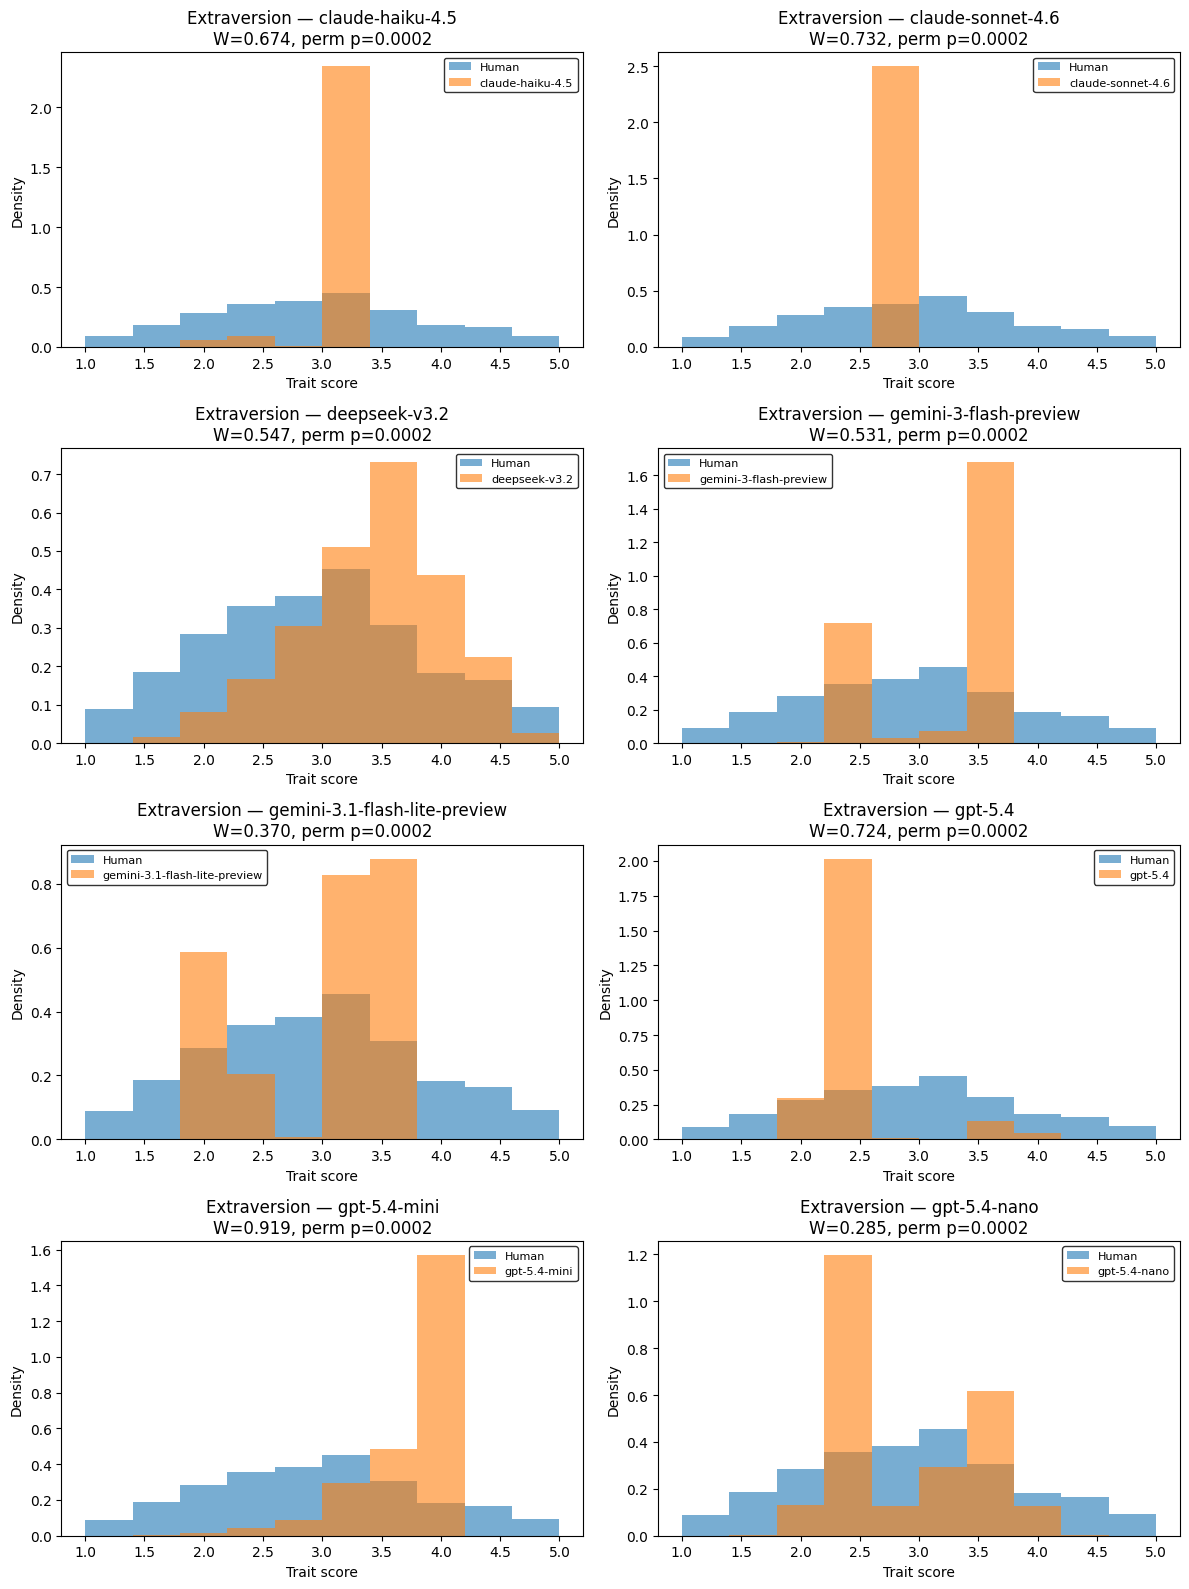

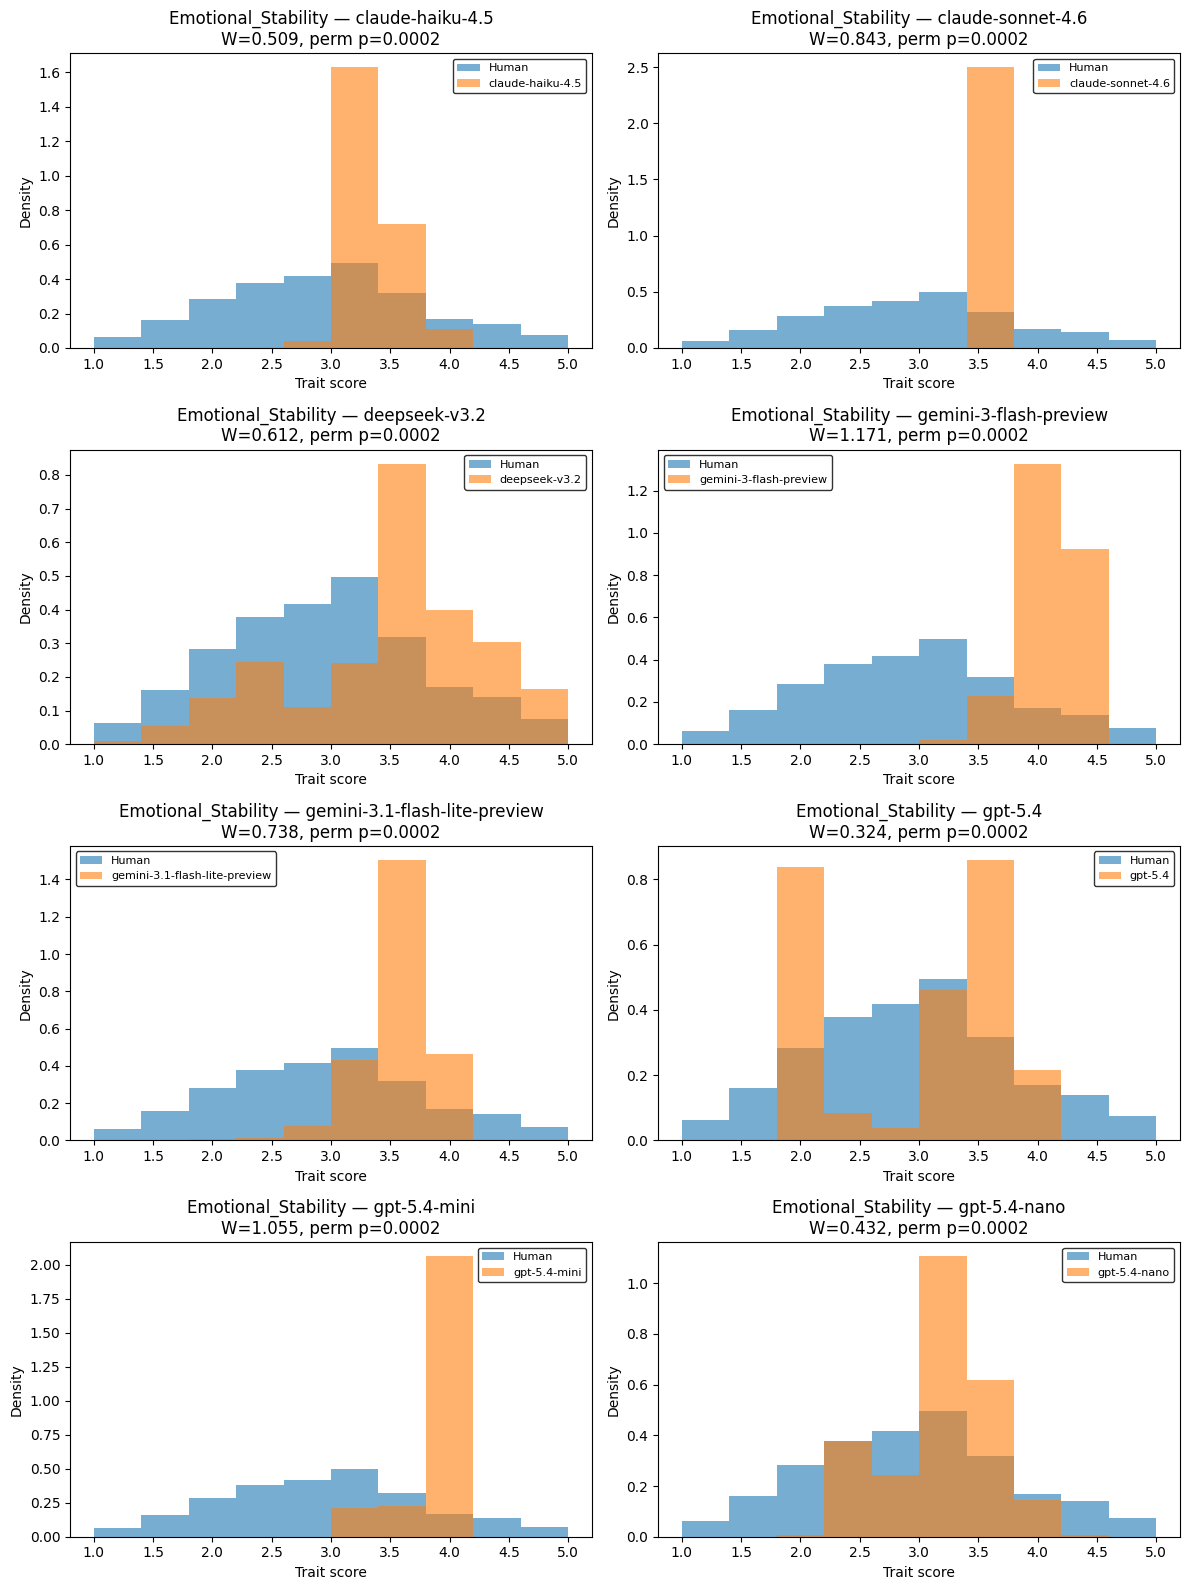

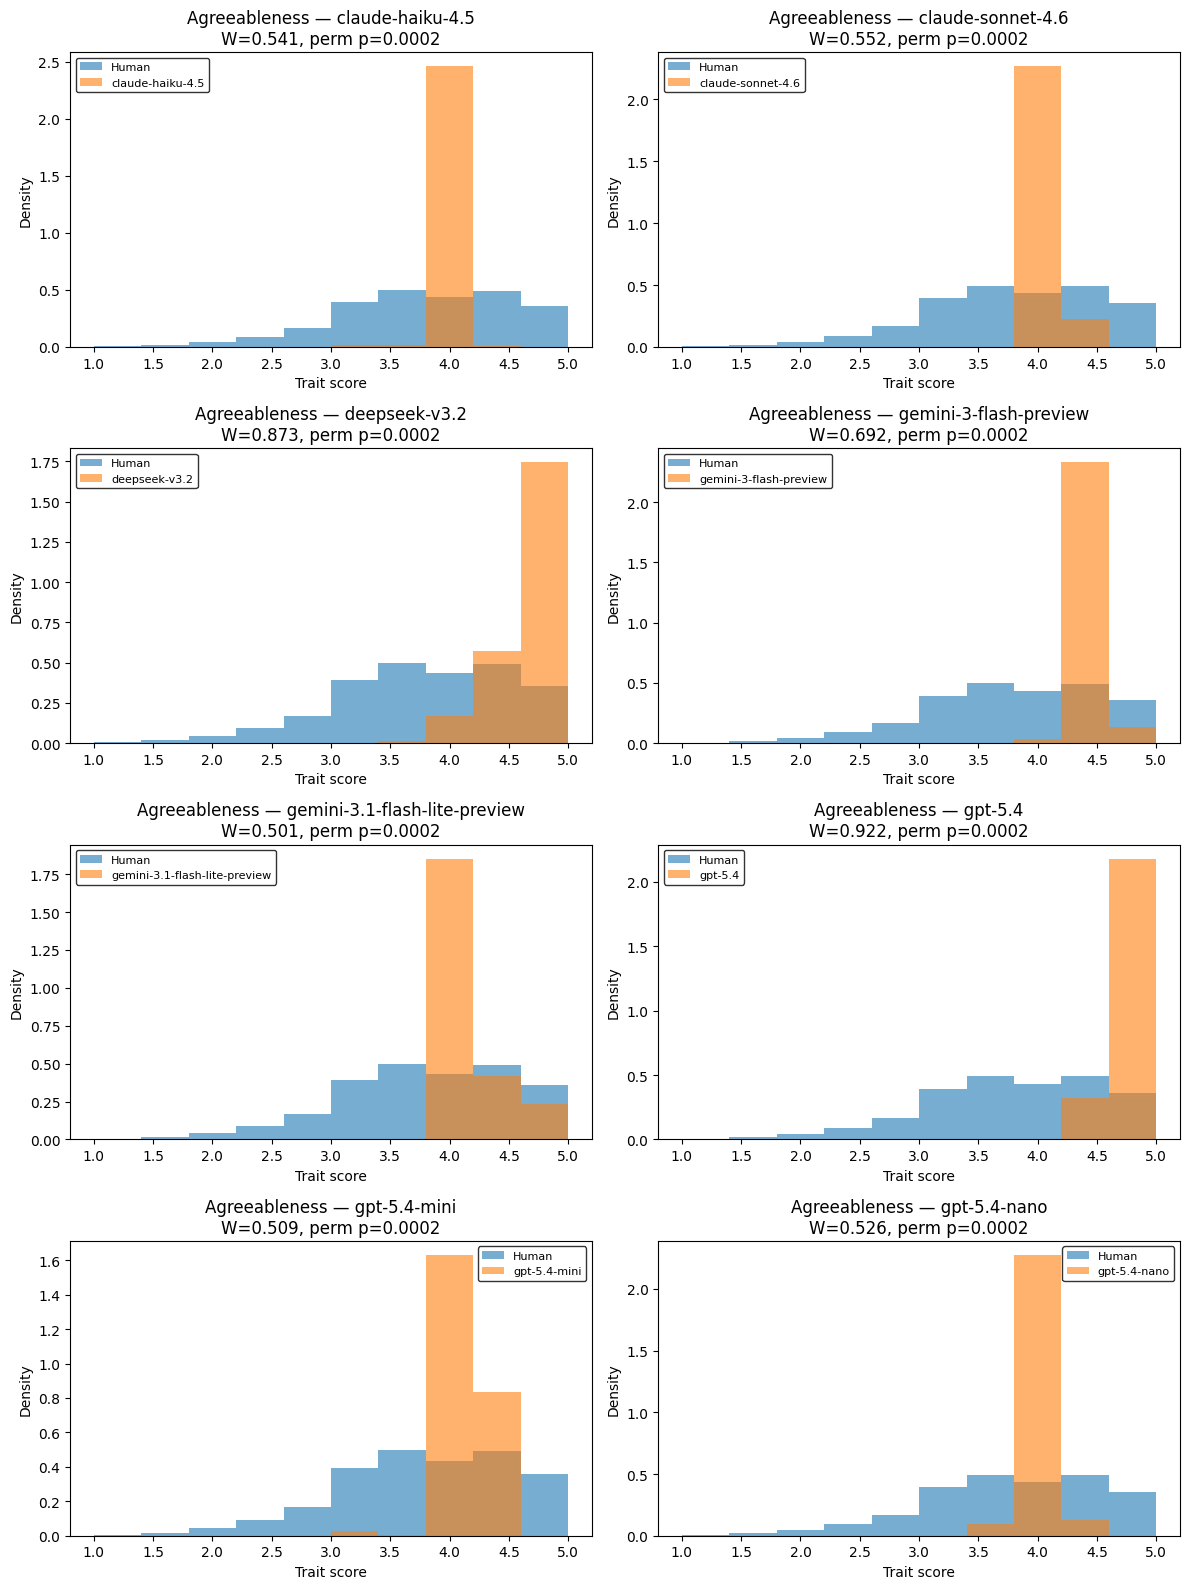

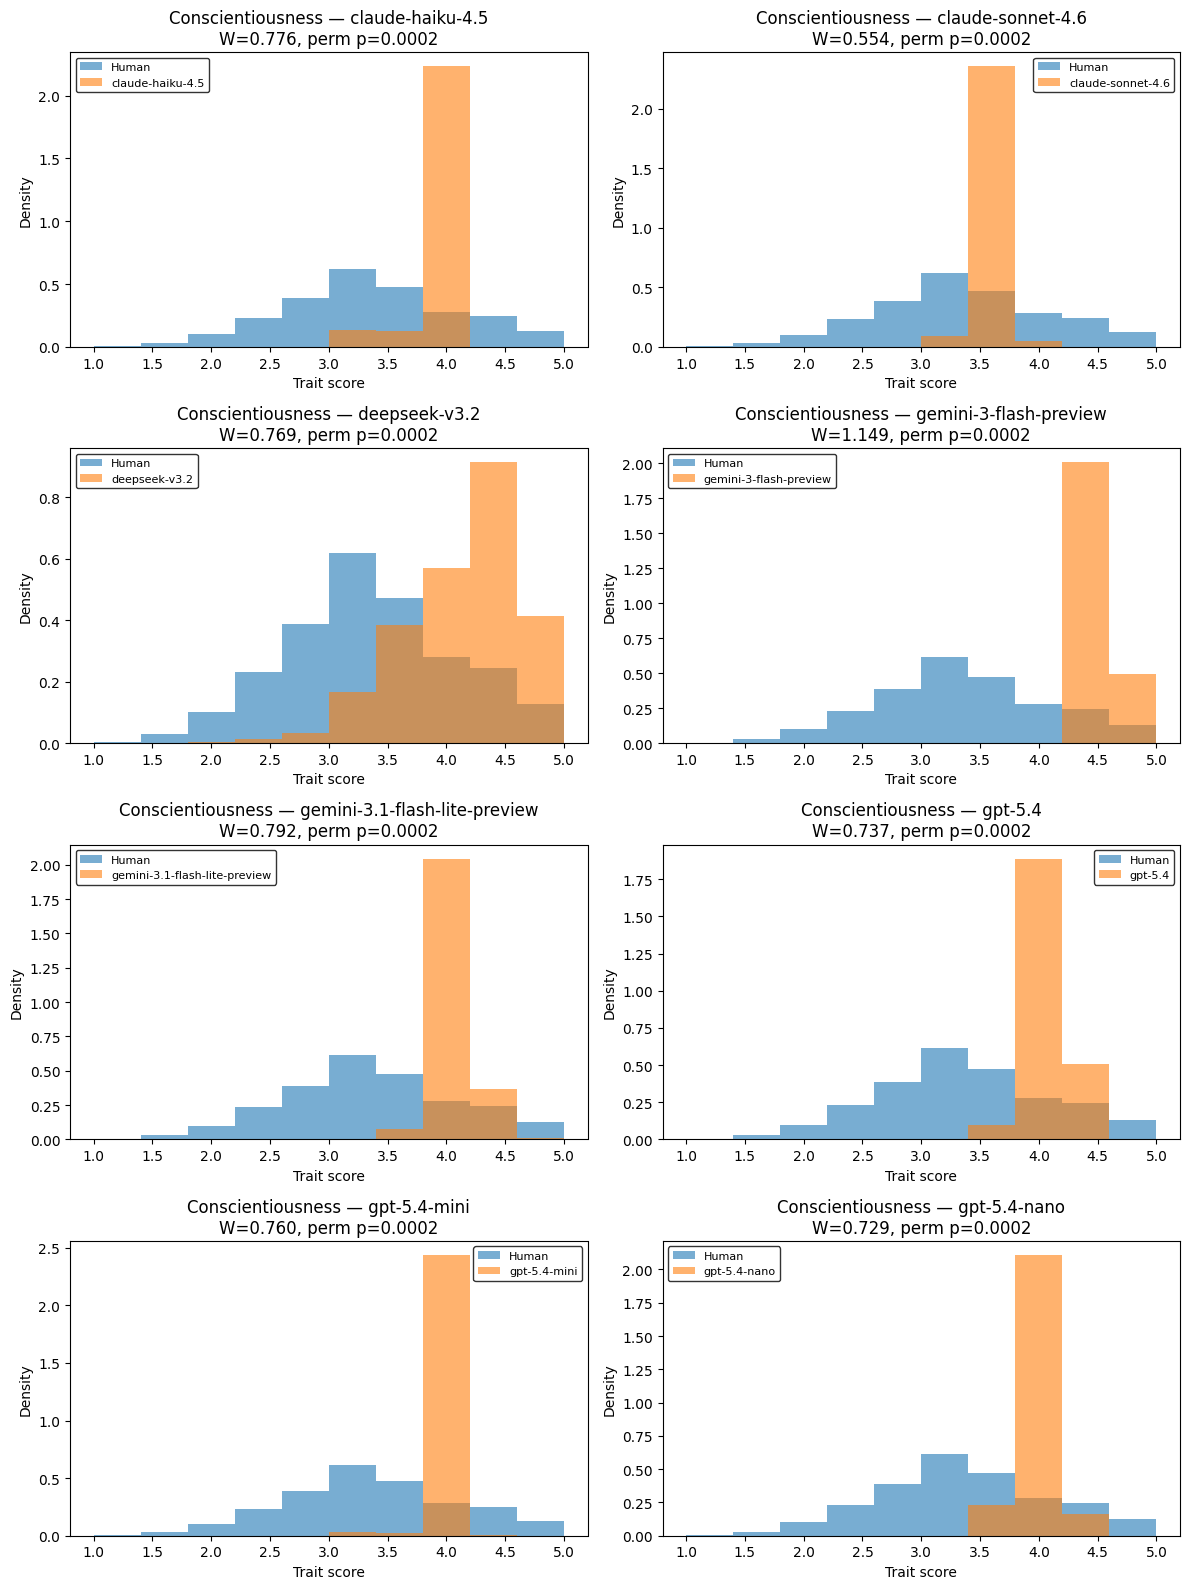

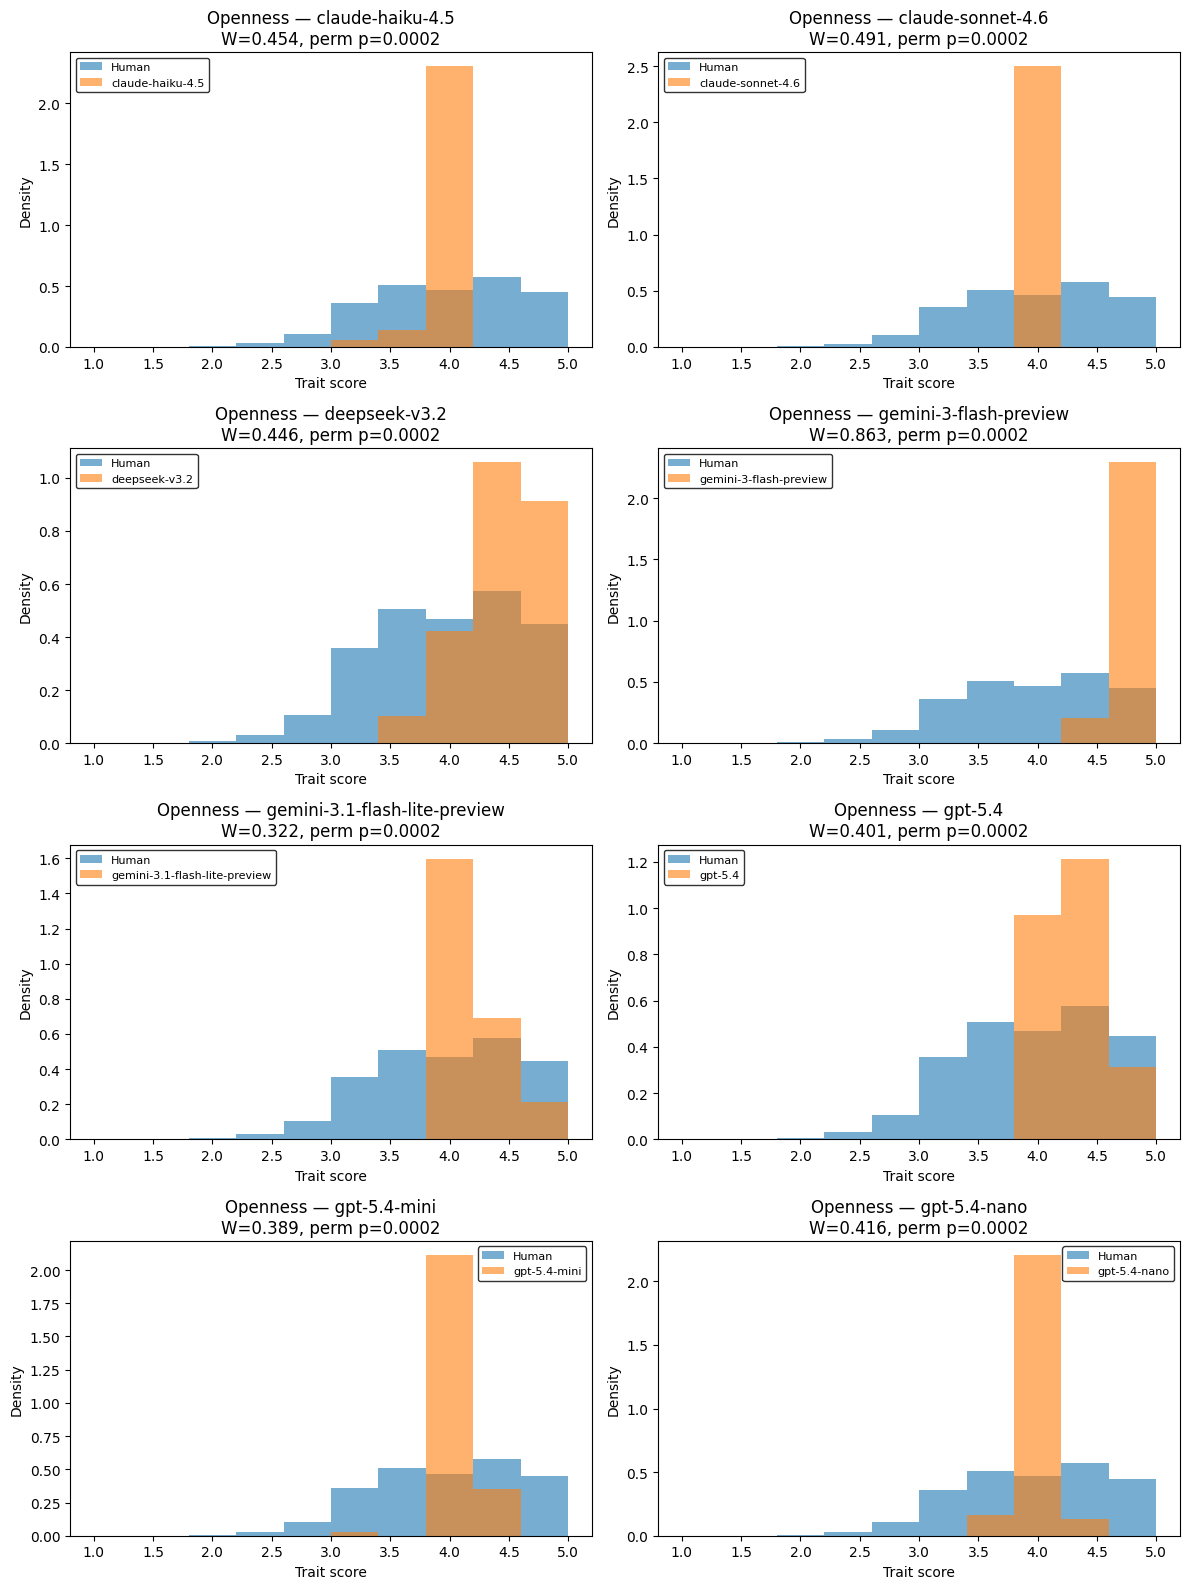

In [13]:

# Figure: histograms for each trait and model overlayed against humans
for trait in TRAIT_PREFIXES:
    fig, axes = plt.subplots(nrows=math.ceil(ai_scored["model"].nunique() / 2), ncols=2, figsize=(12, 16))
    axes = np.array(axes).reshape(-1)
    bins = np.linspace(LIKERT_MIN, LIKERT_MAX, 11)

    for ax, (model_name, model_df) in zip(axes, ai_scored.groupby("model")):
        ax.hist(human_scored[trait], bins=bins, alpha=0.6, density=True, label="Human")
        ax.hist(model_df[trait], bins=bins, alpha=0.6, density=True, label=model_name)
        sub = dist_table[(dist_table["model"] == model_name) & (dist_table["trait"] == trait)].iloc[0]
        ax.set_title(f"{trait} — {model_name}\nW={sub['wasserstein']:.3f}, perm p={sub['wasserstein_perm_p']:.4f}")
        ax.set_xlabel("Trait score")
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)

    for ax in axes[len(ai_scored['model'].unique()):]:
        ax.axis("off")

    plt.tight_layout()
    save_fig(fig, f"level2_{trait}_distribution_overlays")
    plt.show()


# Level 3 — Reliability fidelity

**Question:** Does AI show the same internal consistency as humans?

### Descriptive metrics used
- Cronbach's alpha
- McDonald's omega (one-factor estimate within each trait block)
- corrected item-total correlations
- alpha if item deleted

### Inferential additions in this revised notebook
- bootstrap confidence intervals for alpha and omega
- bootstrap confidence intervals for AI-minus-human differences in alpha and omega
- permutation tests for alpha and omega differences between each model and humans

The inferential layer is intentionally row-resampling based so the notebook remains practical in Colab.

In [14]:
def mcdonalds_omega_onefactor(df_items):
    # Filter out items with zero variance as they lead to singular matrices
    # and would cause issues in correlation matrix calculation.
    df_items_filtered = df_items.loc[:, df_items.var() > 0]

    # If after filtering, there are fewer than 2 items,
    # factor analysis for omega is not meaningful.
    if df_items_filtered.shape[1] < 2:
        return np.nan

    fa = FactorAnalyzer(n_factors=1, rotation=None, method="minres")
    try:
        fa.fit(df_items_filtered)
    except np.linalg.LinAlgError:
        # Catch LinAlgError if the correlation matrix is singular (e.g., perfect multicollinearity
        # among remaining items, or if the number of samples is too small for the items remaining
        # in some specific bootstrap/permutation iteration).
        return np.nan

    loadings = fa.loadings_.flatten()
    uniq = fa.get_uniquenesses()
    numerator = loadings.sum() ** 2
    denominator = numerator + uniq.sum()
    if denominator == 0:
        return np.nan
    return numerator / denominator

def alpha_if_item_deleted(df_items):
    rows = []
    for c in df_items.columns:
        alpha_del = cronbach_alpha_manual(df_items.drop(columns=[c]))
        rows.append({"item": c, "alpha_if_deleted": alpha_del})
    return pd.DataFrame(rows)

def alpha_stat(df):
    return cronbach_alpha_manual(df)

def omega_stat(df):
    return mcdonalds_omega_onefactor(df)

reliability_rows = []
itemtotal_rows = []
alpha_delete_rows = []
rel_infer_rows = []

# humans descriptive + inferential base
human_trait_items = {}
for trait, prefix in TRAIT_PREFIXES.items():
    cols = [f"{prefix}{i}" for i in range(1, 11)]
    items = human_scored[cols]
    human_trait_items[trait] = items.copy()
    alpha = cronbach_alpha_manual(items)
    omega = mcdonalds_omega_onefactor(items)

    alpha_ci_low, alpha_ci_high, _ = bootstrap_ci_rows(
        maybe_downsample_df(items, MAX_N_PER_GROUP_FOR_L3L4_INFERENCE, RNG),
        alpha_stat, n_boot=N_BOOT_L3, seed=42
    )
    omega_ci_low, omega_ci_high, _ = bootstrap_ci_rows(
        maybe_downsample_df(items, MAX_N_PER_GROUP_FOR_L3L4_INFERENCE, RNG),
        omega_stat, n_boot=N_BOOT_L3, seed=43
    )

    reliability_rows.append({
        "group": "Human", "model": "Human", "trait": trait,
        "alpha": alpha, "omega": omega,
        "alpha_ci_low": alpha_ci_low, "alpha_ci_high": alpha_ci_high,
        "omega_ci_low": omega_ci_low, "omega_ci_high": omega_ci_high,
    })
    itc = corrected_item_total_corr(items)
    for item, r in itc.items():
        itemtotal_rows.append({"group": "Human", "model": "Human", "trait": trait, "item": item, "corrected_item_total_r": r})
    aid = alpha_if_item_deleted(items)
    aid["group"] = "Human"
    aid["model"] = "Human"
    aid["trait"] = trait
    alpha_delete_rows.append(aid)

# AI models
for model_name, model_df in ai_scored.groupby("model"):
    for trait, prefix in TRAIT_PREFIXES.items():
        cols = [f"{prefix}{i}" for i in range(1, 11)]
        items = model_df[cols]
        alpha = cronbach_alpha_manual(items)
        omega = mcdonalds_omega_onefactor(items)

        items_ds = maybe_downsample_df(items, MAX_N_PER_GROUP_FOR_L3L4_INFERENCE, RNG)
        human_ds = maybe_downsample_df(human_trait_items[trait], MAX_N_PER_GROUP_FOR_L3L4_INFERENCE, RNG)

        alpha_ci_low, alpha_ci_high, _ = bootstrap_ci_rows(items_ds, alpha_stat, n_boot=N_BOOT_L3, seed=100)
        omega_ci_low, omega_ci_high, _ = bootstrap_ci_rows(items_ds, omega_stat, n_boot=N_BOOT_L3, seed=101)

        alpha_diff_obs, alpha_perm_p = permutation_pvalue_rows(
            human_ds, items_ds, alpha_stat, n_perm=N_PERM_L3, seed=102, alternative="two-sided"
        )
        omega_diff_obs, omega_perm_p = permutation_pvalue_rows(
            human_ds, items_ds, omega_stat, n_perm=N_PERM_L3, seed=103, alternative="two-sided"
        )
        alpha_diff_ci_low, alpha_diff_ci_high, _ = bootstrap_diff_ci_rows(
            human_ds, items_ds, alpha_stat, n_boot=N_BOOT_L3, seed=104
        )
        omega_diff_ci_low, omega_diff_ci_high, _ = bootstrap_diff_ci_rows(
            human_ds, items_ds, omega_stat, n_boot=N_BOOT_L3, seed=105
        )

        reliability_rows.append({
            "group": "AI", "model": model_name, "trait": trait,
            "alpha": alpha, "omega": omega,
            "alpha_ci_low": alpha_ci_low, "alpha_ci_high": alpha_ci_high,
            "omega_ci_low": omega_ci_high if False else omega_ci_low, "omega_ci_high": omega_ci_high,
        })

        rel_infer_rows.append({
            "model": model_name,
            "trait": trait,
            "n_used_human": len(human_ds),
            "n_used_ai": len(items_ds),
            "alpha_diff_ai_minus_human": alpha_diff_obs,
            "alpha_diff_ci_low": alpha_diff_ci_low,
            "alpha_diff_ci_high": alpha_diff_ci_high,
            "alpha_perm_p": alpha_perm_p,
            "omega_diff_ai_minus_human": omega_diff_obs,
            "omega_diff_ci_low": omega_diff_ci_low,
            "omega_diff_ci_high": omega_diff_ci_high,
            "omega_perm_p": omega_perm_p,
        })

        itc = corrected_item_total_corr(items)
        for item, r in itc.items():
            itemtotal_rows.append({"group": "AI", "model": model_name, "trait": trait,
                                   "item": item, "corrected_item_total_r": r})
        aid = alpha_if_item_deleted(items)
        aid["group"] = "AI"
        aid["model"] = model_name
        aid["trait"] = trait
        alpha_delete_rows.append(aid)

reliability_table = pd.DataFrame(reliability_rows)
itemtotal_table = pd.DataFrame(itemtotal_rows)
alpha_deleted_table = pd.concat(alpha_delete_rows, ignore_index=True)
rel_infer_table = pd.DataFrame(rel_infer_rows)

if len(rel_infer_table):
    rel_infer_table["alpha_perm_p_fdr"] = multipletests(rel_infer_table["alpha_perm_p"], method="fdr_bh")[1]
    rel_infer_table["omega_perm_p_fdr"] = multipletests(rel_infer_table["omega_perm_p"], method="fdr_bh")[1]

# Human-vs-model reliability comparison view
rel_compare = reliability_table.merge(
    reliability_table.loc[reliability_table["group"] == "Human",
                          ["trait", "alpha", "omega", "alpha_ci_low", "alpha_ci_high", "omega_ci_low", "omega_ci_high"]]
    .rename(columns={
        "alpha": "human_alpha",
        "omega": "human_omega",
        "alpha_ci_low": "human_alpha_ci_low",
        "alpha_ci_high": "human_alpha_ci_high",
        "omega_ci_low": "human_omega_ci_low",
        "omega_ci_high": "human_omega_ci_high",
    }),
    on="trait",
    how="left"
)
rel_compare["alpha_diff_ai_minus_human"] = rel_compare["alpha"] - rel_compare["human_alpha"]
rel_compare["omega_diff_ai_minus_human"] = rel_compare["omega"] - rel_compare["human_omega"]
rel_compare = rel_compare.loc[rel_compare["group"] == "AI"].sort_values(["trait", "model"]).reset_index(drop=True)

if len(rel_infer_table):
    rel_compare = rel_compare.merge(
        rel_infer_table,
        on=["model", "trait"],
        how="left"
    )

save_df(reliability_table, "level3_reliability_raw")
save_df(rel_compare, "level3_reliability_model_vs_human")
save_df(rel_infer_table, "level3_reliability_inferential")
save_df(itemtotal_table, "level3_item_total_correlations")
save_df(alpha_deleted_table, "level3_alpha_if_item_deleted")

display(rel_compare.head(15))

,group,model,trait,alpha,omega,alpha_ci_low,alpha_ci_high,omega_ci_low,omega_ci_high,human_alpha,human_omega,human_alpha_ci_low,human_alpha_ci_high,human_omega_ci_low,human_omega_ci_high,alpha_diff_ai_minus_human_x,omega_diff_ai_minus_human_x,n_used_human,n_used_ai,alpha_diff_ai_minus_human_y,alpha_diff_ci_low,alpha_diff_ci_high,alpha_perm_p,omega_diff_ai_minus_human_y,omega_diff_ci_low,omega_diff_ci_high,omega_perm_p,alpha_perm_p_fdr,omega_perm_p_fdr
0,AI,claude-haiku-4.5,Agreeableness,0.680418,0.925052,0.524975,0.703408,0.895063,0.933343,0.852490,0.859966,0.848665,0.860829,0.851971,0.863911,-0.172072,0.065085,5000,5000,-0.224004,-0.343681,-0.144814,0.000999,NaN,0.039129,0.077151,0.000999,0.001110,0.001052
1,AI,claude-sonnet-4.6,Agreeableness,0.067990,0.647070,0.048970,0.164282,0.630804,0.740747,0.852490,0.859966,0.848665,0.860829,0.851971,0.863911,-0.784500,-0.212896,5000,5000,-0.747393,-0.809732,-0.690174,0.000999,-0.170754,-0.230388,-0.121641,0.000999,0.001110,0.001052
2,AI,deepseek-v3.2,Agreeableness,0.825225,0.832767,0.808437,0.823799,0.816741,0.833250,0.852490,0.859966,0.848665,0.860829,0.851971,0.863911,-0.027265,-0.027200,5000,5000,-0.036860,-0.047051,-0.026201,0.000999,-0.035864,-0.046102,-0.025292,0.000999,0.001110,0.001052
3,AI,gemini-3-flash-preview,Agreeableness,0.698036,0.675324,0.684728,0.708639,0.658365,0.706575,0.852490,0.859966,0.848665,0.860829,0.851971,0.863911,-0.154454,-0.184642,5000,5000,-0.154579,-0.169287,-0.139808,0.000999,-0.179692,-0.202072,-0.153475,0.000999,0.001110,0.001052
4,AI,gemini-3.1-flash-lite-preview,Agreeableness,0.879537,0.894135,0.874015,0.885264,0.887489,0.899094,0.852490,0.859966,0.848665,0.860829,0.851971,0.863911,0.027046,0.034169,5000,5000,0.029858,0.020957,0.037918,0.000999,0.035567,0.027559,0.043249,0.000999,0.001110,0.001052
5,AI,gpt-5.4,Agreeableness,0.554789,0.556548,0.540529,0.563874,0.521907,0.609943,0.852490,0.859966,0.848665,0.860829,0.851971,0.863911,-0.297702,-0.303418,5000,5000,-0.299697,-0.313014,-0.284307,0.000999,-0.297933,-0.328700,-0.247724,0.000999,0.001110,0.001052
6,AI,gpt-5.4-mini,Agreeableness,0.836031,0.943408,0.823918,0.864081,0.942147,0.954979,0.852490,0.859966,0.848665,0.860829,0.851971,0.863911,-0.016460,0.083442,5000,5000,-0.010392,-0.032530,0.010146,0.120879,0.086704,0.077706,0.094612,0.000999,0.120879,0.001052
7,AI,gpt-5.4-nano,Agreeableness,0.269533,0.279561,0.224732,0.289454,0.251116,0.320700,0.852490,0.859966,0.848665,0.860829,0.851971,0.863911,-0.582957,-0.580405,5000,5000,-0.595386,-0.629825,-0.564463,0.000999,-0.588555,-0.612603,-0.537503,0.000999,0.001110,0.001052
8,AI,claude-haiku-4.5,Conscientiousness,0.913588,0.924773,0.906145,0.917892,0.917671,0.929314,0.834218,0.834418,0.828755,0.841853,0.830705,0.844306,0.079370,0.090355,5000,5000,0.082863,0.073516,0.092687,0.000999,0.093909,0.084936,0.103788,0.000999,0.001110,0.001052
9,AI,claude-sonnet-4.6,Conscientiousness,0.457886,NaN,0.403207,0.475939,NaN,NaN,0.834218,0.834418,0.828755,0.841853,0.830705,0.844306,-0.376332,NaN,5000,5000,-0.389341,-0.428740,-0.358594,0.000999,NaN,NaN,NaN,0.000999,0.001110,0.001052


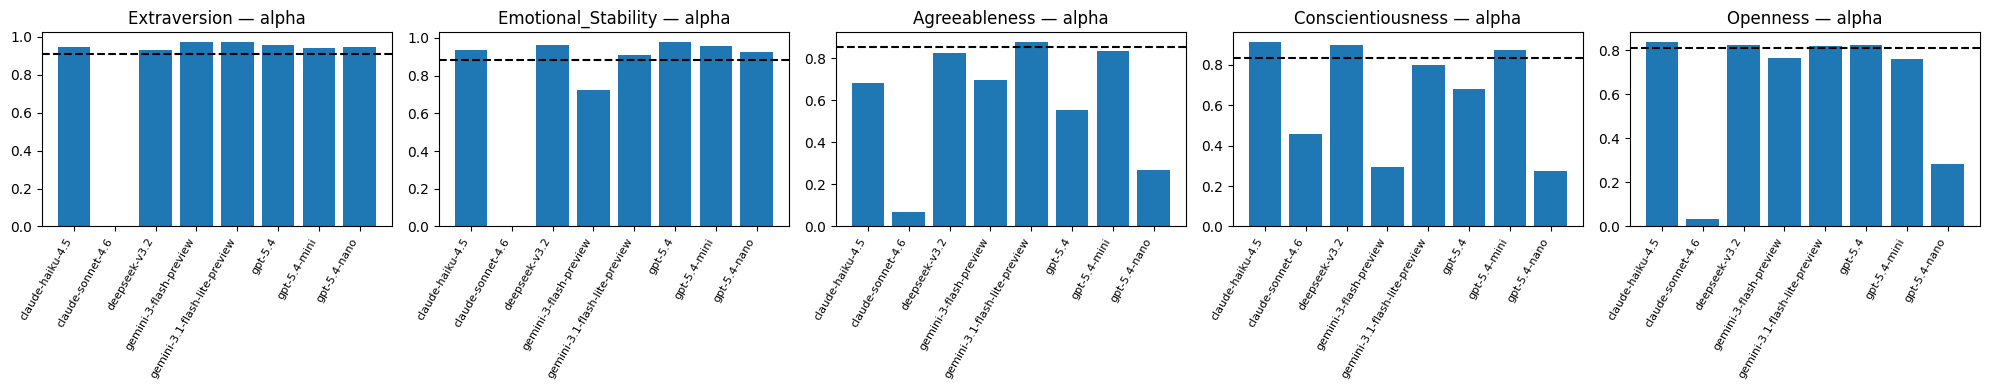

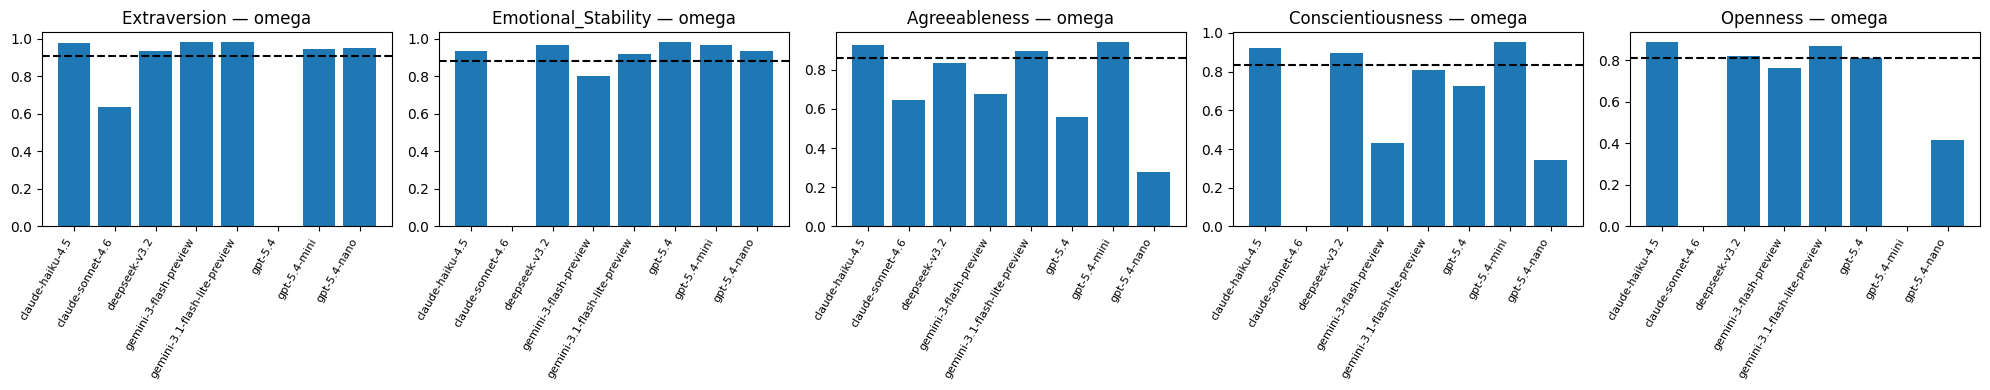

In [15]:

# Figure: alpha and omega by trait
for metric in ["alpha", "omega"]:
    fig, axes = plt.subplots(1, len(TRAIT_PREFIXES), figsize=(20, 4), sharey=False)
    if len(TRAIT_PREFIXES) == 1:
        axes = [axes]
    for ax, trait in zip(axes, TRAIT_PREFIXES):
        sub = reliability_table.loc[reliability_table["trait"] == trait].copy()
        ai_sub = sub.loc[sub["group"] == "AI"]
        human_val = sub.loc[sub["group"] == "Human", metric].iloc[0]
        ax.bar(np.arange(len(ai_sub)), ai_sub[metric])
        ax.axhline(human_val, linestyle="--")
        ax.set_xticks(np.arange(len(ai_sub)))
        ax.set_xticklabels(ai_sub["model"], rotation=60, ha="right", fontsize=8)
        ax.set_title(f"{trait} — {metric}")
    plt.tight_layout()
    save_fig(fig, f"level3_{metric}_comparison")
    plt.show()


# Level 4 — Structural fidelity

**Question:** Does AI reproduce the internal psychometric structure of human personality?

### Descriptive analyses used
- trait-level correlation matrix comparison
- item-level correlation matrix comparison
- exploratory factor analysis (5 factors)
- Tucker congruence of factor loading matrices versus humans

### Inferential additions in this revised notebook
- bootstrap confidence intervals for trait-correlation and item-correlation similarity
- permutation tests for Frobenius-distance departures in trait and item correlation structure
- bootstrap confidence intervals for Tucker-style loading congruence summaries
- permutation tests for Tucker discrepancy where stable factor recovery is available

This notebook still prioritizes **EFA-based structure comparison** rather than full multi-group CFA, because it is more robust and practical in Colab.

In [16]:
def corr_frobenius(a, b):
    return np.sqrt(((a - b) ** 2).to_numpy().sum())

def matrix_upper_tri_vector(df_corr):
    m = df_corr.to_numpy()
    idx = np.triu_indices_from(m, k=1)
    return m[idx]

def factor_loadings(df_items, n_factors=5):
    fa = FactorAnalyzer(n_factors=n_factors, rotation="varimax", method="minres")
    try:
        fa.fit(df_items)
        load = pd.DataFrame(
            fa.loadings_,
            index=df_items.columns,
            columns=[f"F{i+1}" for i in range(n_factors)]
        )
    except (np.linalg.LinAlgError, ValueError):
        load = pd.DataFrame(np.nan, index=df_items.columns, columns=[f"F{i+1}" for i in range(n_factors)])
        fa.get_factor_variance = lambda: (np.zeros(n_factors), np.zeros(n_factors), np.zeros(n_factors))
    return load, fa

def tucker_congruence(load_a, load_b):
    A = load_a.copy()
    B = load_b.copy()
    scores = np.zeros((A.shape[1], B.shape[1]))
    for i, ca in enumerate(A.columns):
        for j, cb in enumerate(B.columns):
            a = A[ca].to_numpy()
            b = B[cb].to_numpy()
            # Handle NaNs that might have been returned by factor_loadings
            if np.isnan(a).any() or np.isnan(b).any():
                scores[i, j] = np.nan
                continue
            denom = np.sqrt((a**2).sum() * (b**2).sum())
            scores[i, j] = np.nan if denom == 0 else np.dot(a, b) / denom
    return pd.DataFrame(scores, index=A.columns, columns=B.columns)

def trait_corr_similarity_from_scored(df):
    corr = df[list(TRAIT_PREFIXES.keys())].corr()
    vec_h = matrix_upper_tri_vector(human_trait_corr)
    vec_m = matrix_upper_tri_vector(corr)
    return np.corrcoef(vec_h, vec_m)[0, 1]

def item_corr_similarity_from_scored(df):
    corr = df[ITEM_COLS].corr()
    vec_h = matrix_upper_tri_vector(human_item_corr)
    vec_m = matrix_upper_tri_vector(corr)
    return np.corrcoef(vec_h, vec_m)[0, 1]

def trait_corr_frob_stat(df):
    return corr_frobenius(human_trait_corr, df[list(TRAIT_PREFIXES.keys())].corr())

def item_corr_frob_stat(df):
    return corr_frobenius(human_item_corr, df[ITEM_COLS].corr())

def mean_abs_tucker_stat(df):
    model_loadings, _ = factor_loadings(df[ITEM_COLS], n_factors=5)
    congr = tucker_congruence(human_loadings, model_loadings)
    return np.nanmean(np.abs(congr.to_numpy()))

human_trait_corr = human_scored[list(TRAIT_PREFIXES.keys())].corr()
human_item_corr = human_scored[ITEM_COLS].corr()
human_loadings, human_fa = factor_loadings(human_scored[ITEM_COLS], n_factors=5)

struct_rows = []
congruence_tables = {}
struct_infer_rows = []

for model_name, model_df in ai_scored.groupby("model"):
    model_trait_corr = model_df[list(TRAIT_PREFIXES.keys())].corr()
    model_item_corr = model_df[ITEM_COLS].corr()

    trait_frob = corr_frobenius(human_trait_corr, model_trait_corr)
    item_frob = corr_frobenius(human_item_corr, model_item_corr)

    trait_vec_h = matrix_upper_tri_vector(human_trait_corr)
    trait_vec_m = matrix_upper_tri_vector(model_trait_corr)
    item_vec_h = matrix_upper_tri_vector(human_item_corr)
    item_vec_m = matrix_upper_tri_vector(model_item_corr)

    trait_mat_r = np.corrcoef(trait_vec_h, trait_vec_m)[0, 1]
    item_mat_r = np.corrcoef(item_vec_h, item_vec_m)[0, 1]

    model_loadings, model_fa = factor_loadings(model_df[ITEM_COLS], n_factors=5)
    congr = tucker_congruence(human_loadings, model_loadings)
    congruence_tables[model_name] = congr

    struct_rows.append({
        "model": model_name,
        "trait_corr_frobenius": trait_frob,
        "trait_corr_matrix_r": trait_mat_r,
        "item_corr_frobenius": item_frob,
        "item_corr_matrix_r": item_mat_r,
        "human_variance_explained_5f": human_fa.get_factor_variance()[1].sum(),
        "model_variance_explained_5f": model_fa.get_factor_variance()[1].sum(),
        "mean_abs_tucker_congruence": np.nanmean(np.abs(congr.to_numpy())),
        "max_abs_tucker_congruence": np.nanmax(np.abs(congr.to_numpy())),
    })

    human_ds = maybe_downsample_df(human_scored, MAX_N_PER_GROUP_FOR_L3L4_INFERENCE, RNG)
    model_ds = maybe_downsample_df(model_df, MAX_N_PER_GROUP_FOR_L3L4_INFERENCE, RNG)

    trait_r_ci_low, trait_r_ci_high, _ = bootstrap_diff_ci_rows(
        human_ds, model_ds, trait_corr_similarity_from_scored, n_boot=1, seed=0
    )  # placeholder to keep variable names defined

    # bootstrap observed-similarity CIs on the model sample relative to the fixed human reference
    trait_r_ci_low, trait_r_ci_high, _ = bootstrap_ci_rows(
        model_ds, trait_corr_similarity_from_scored, n_boot=N_BOOT_L4, seed=200
    )
    item_r_ci_low, item_r_ci_high, _ = bootstrap_ci_rows(
        model_ds, item_corr_similarity_from_scored, n_boot=N_BOOT_L4, seed=201
    )
    tucker_ci_low, tucker_ci_high, _ = bootstrap_ci_rows(
        model_ds, mean_abs_tucker_stat, n_boot=N_BOOT_L4, seed=202
    )

    trait_frob_diff, trait_frob_perm_p = permutation_pvalue_rows(
        human_ds, model_ds, trait_corr_frob_stat, n_perm=N_PERM_L4, seed=203, alternative="greater"
    )
    item_frob_diff, item_frob_perm_p = permutation_pvalue_rows(
        human_ds, model_ds, item_corr_frob_stat, n_perm=N_PERM_L4, seed=204, alternative="greater"
    )
    tucker_diff, tucker_perm_p = permutation_pvalue_rows(
        human_ds, model_ds, mean_abs_tucker_stat, n_perm=N_PERM_L4, seed=205, alternative="greater"
    )

    struct_infer_rows.append({
        "model": model_name,
        "n_used_human": len(human_ds),
        "n_used_ai": len(model_ds),
        "trait_corr_matrix_r_ci_low": trait_r_ci_low,
        "trait_corr_matrix_r_ci_high": trait_r_ci_high,
        "item_corr_matrix_r_ci_low": item_r_ci_low,
        "item_corr_matrix_r_ci_high": item_r_ci_high,
        "mean_abs_tucker_ci_low": tucker_ci_low,
        "mean_abs_tucker_ci_high": tucker_ci_high,
        "trait_corr_frobenius_perm_stat_diff": trait_frob_diff,
        "trait_corr_frobenius_perm_p": trait_frob_perm_p,
        "item_corr_frobenius_perm_stat_diff": item_frob_diff,
        "item_corr_frobenius_perm_p": item_frob_perm_p,
        "mean_abs_tucker_perm_stat_diff": tucker_diff,
        "mean_abs_tucker_perm_p": tucker_perm_p,
    })

struct_table = pd.DataFrame(struct_rows).sort_values("model").reset_index(drop=True)
struct_infer_table = pd.DataFrame(struct_infer_rows).sort_values("model").reset_index(drop=True)

if len(struct_infer_table):
    struct_infer_table["trait_corr_frobenius_perm_p_fdr"] = multipletests(struct_infer_table["trait_corr_frobenius_perm_p"], method="fdr_bh")[1]
    struct_infer_table["item_corr_frobenius_perm_p_fdr"] = multipletests(struct_infer_table["item_corr_frobenius_perm_p"], method="fdr_bh")[1]
    struct_infer_table["mean_abs_tucker_perm_p_fdr"] = multipletests(struct_infer_table["mean_abs_tucker_perm_p"], method="fdr_bh")[1]
    struct_table = struct_table.merge(struct_infer_table, on="model", how="left")

save_df(struct_table, "level4_structural_fidelity_summary")
save_df(struct_infer_table, "level4_structural_fidelity_inferential")
display(struct_table)

,model,trait_corr_frobenius,trait_corr_matrix_r,item_corr_frobenius,item_corr_matrix_r,human_variance_explained_5f,model_variance_explained_5f,mean_abs_tucker_congruence,max_abs_tucker_congruence,n_used_human,n_used_ai,trait_corr_matrix_r_ci_low,trait_corr_matrix_r_ci_high,item_corr_matrix_r_ci_low,item_corr_matrix_r_ci_high,mean_abs_tucker_ci_low,mean_abs_tucker_ci_high,trait_corr_frobenius_perm_stat_diff,trait_corr_frobenius_perm_p,item_corr_frobenius_perm_stat_diff,item_corr_frobenius_perm_p,mean_abs_tucker_perm_stat_diff,mean_abs_tucker_perm_p,trait_corr_frobenius_perm_p_fdr,item_corr_frobenius_perm_p_fdr,mean_abs_tucker_perm_p_fdr
0,claude-haiku-4.5,1.365052,-0.464200,13.259733,0.477727,0.426993,0.727554,0.297858,0.908351,5000,5000,-0.474304,-0.417690,0.465013,0.502222,0.289028,0.299000,1.249293,0.000999,12.229101,0.000999,-0.022255,1.000000,0.000999,0.000999,1.000000
1,claude-sonnet-4.6,0.608703,0.203871,NaN,NaN,0.426993,0.000000,NaN,NaN,5000,5000,0.144146,0.304373,NaN,NaN,NaN,NaN,0.526325,0.000999,NaN,0.000999,NaN,0.000999,0.000999,0.000999,0.001332
2,deepseek-v3.2,1.387951,0.152190,9.113935,0.733477,0.426993,0.520843,0.405396,0.945455,5000,5000,0.114075,0.229188,0.718254,0.738797,0.398949,0.407689,1.306285,0.000999,8.322260,0.000999,0.082005,0.000999,0.000999,0.000999,0.001332
3,gemini-3-flash-preview,0.977807,0.274739,NaN,NaN,0.426993,0.000000,NaN,NaN,5000,5000,0.214497,0.273979,NaN,NaN,NaN,NaN,0.953038,0.000999,NaN,0.000999,NaN,0.000999,0.000999,0.000999,0.001332
4,gemini-3.1-flash-lite-preview,1.863132,-0.105030,NaN,NaN,0.426993,0.000000,NaN,NaN,5000,5000,-0.125186,-0.055311,NaN,NaN,NaN,NaN,1.820481,0.000999,NaN,0.000999,NaN,0.000999,0.000999,0.000999,0.001332
5,gpt-5.4,1.150008,-0.133005,NaN,NaN,0.426993,0.000000,NaN,NaN,5000,5000,-0.153270,-0.077677,NaN,NaN,NaN,NaN,1.058375,0.000999,NaN,0.000999,NaN,0.000999,0.000999,0.000999,0.001332
6,gpt-5.4-mini,1.924104,-0.376617,19.001849,0.322536,0.426993,0.777854,0.331940,0.938069,5000,5000,-0.395664,-0.342078,0.303196,0.352514,0.326426,0.362685,1.829663,0.000999,17.959063,0.000999,0.018319,0.000999,0.000999,0.000999,0.001332
7,gpt-5.4-nano,0.456536,0.113977,7.347546,0.637440,0.426993,0.332408,0.289588,0.951609,5000,5000,-0.055646,0.198603,0.625059,0.638494,0.256767,0.273589,0.424762,0.000999,6.677011,0.000999,-0.055257,1.000000,0.000999,0.000999,1.000000


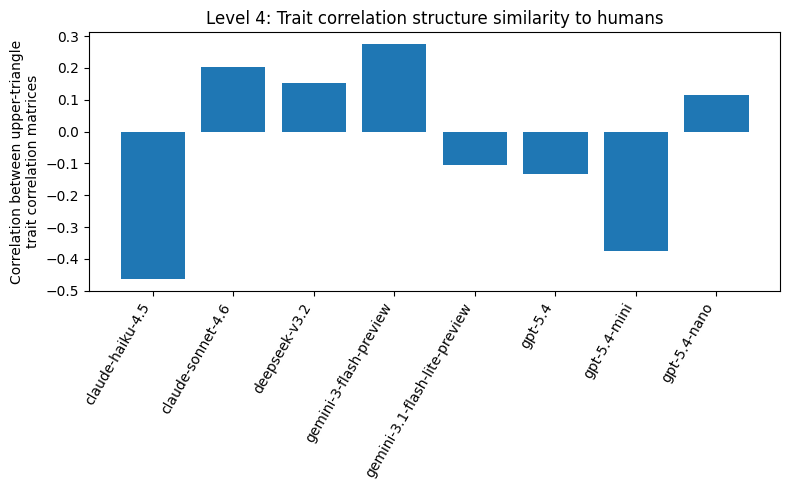

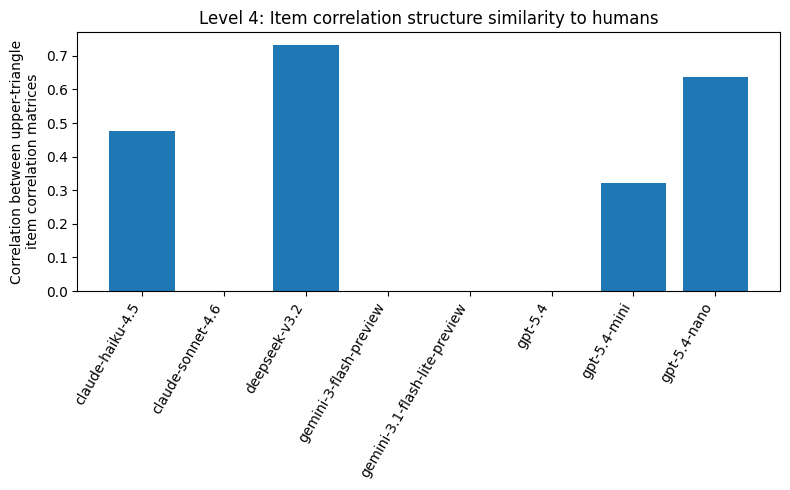

In [17]:

# Figures: heatmaps of trait correlation matrices and item-correlation similarity summary
fig, axes = plt.subplots(1, 1, figsize=(8, 5))
axes.bar(np.arange(len(struct_table)), struct_table["trait_corr_matrix_r"])
axes.set_xticks(np.arange(len(struct_table)))
axes.set_xticklabels(struct_table["model"], rotation=60, ha="right")
axes.set_ylabel("Correlation between upper-triangle\ntrait correlation matrices")
axes.set_title("Level 4: Trait correlation structure similarity to humans")
plt.tight_layout()
save_fig(fig, "level4_trait_corr_similarity")
plt.show()

fig, axes = plt.subplots(1, 1, figsize=(8, 5))
axes.bar(np.arange(len(struct_table)), struct_table["item_corr_matrix_r"])
axes.set_xticks(np.arange(len(struct_table)))
axes.set_xticklabels(struct_table["model"], rotation=60, ha="right")
axes.set_ylabel("Correlation between upper-triangle\nitem correlation matrices")
axes.set_title("Level 4: Item correlation structure similarity to humans")
plt.tight_layout()
save_fig(fig, "level4_item_corr_similarity")
plt.show()


In [18]:

# Optional: inspect one model's Tucker congruence matrix
example_model = struct_table["model"].iloc[0]
print("Example model for congruence matrix:", example_model)
display(congruence_tables[example_model])


Example model for congruence matrix: claude-haiku-4.5


,F1,F2,F3,F4,F5
F1,0.105551,0.908351,0.301510,0.128977,0.161669
F2,0.083929,0.127651,0.178453,0.852660,0.696373
F3,0.688204,0.146717,0.188437,0.107028,-0.033664
F4,0.329648,0.139003,0.758568,0.245164,0.069210
F5,0.490796,0.152014,0.483370,0.048995,0.020503



# Level 5 — Behavioral fidelity

**Question:** Does AI answer like a human respondent?

### Analyses used
- response-option frequency comparison (chi-square, Cramér's V)
- acquiescence bias
- extreme response bias
- midpoint bias
- reverse-item sensitivity
- response entropy
- profile diversity in 5D trait space


In [19]:

def response_option_counts(df, item_cols):
    vals = pd.Series(df[item_cols].to_numpy().ravel())
    counts = vals.value_counts().sort_index()
    counts = counts.reindex(range(LIKERT_MIN, LIKERT_MAX + 1), fill_value=0)
    return counts

def response_style_metrics(df, item_cols, reverse_cols):
    vals = df[item_cols].to_numpy().ravel()
    counts = pd.Series(vals).value_counts().sort_index().reindex(range(LIKERT_MIN, LIKERT_MAX + 1), fill_value=0)

    agree_prop = ((vals >= 4).sum()) / len(vals)
    extreme_prop = (((vals == LIKERT_MIN) | (vals == LIKERT_MAX)).sum()) / len(vals)
    midpoint = int(round((LIKERT_MIN + LIKERT_MAX) / 2))
    midpoint_prop = ((vals == midpoint).sum()) / len(vals)
    ent = shannon_entropy_from_counts(counts)

    forward_cols = [c for c in item_cols if c not in reverse_cols]
    reverse_cols_local = [c for c in item_cols if c in reverse_cols]

    forward_mean = df[forward_cols].to_numpy().mean() if forward_cols else np.nan
    reverse_mean_raw = df[reverse_cols_local].to_numpy().mean() if reverse_cols_local else np.nan
    reverse_mean_scored = reverse_code(df[reverse_cols_local], reverse_cols_local, LIKERT_MIN, LIKERT_MAX).to_numpy().mean() if reverse_cols_local else np.nan

    trait_profiles = df[list(TRAIT_PREFIXES.keys())].to_numpy()
    idx = np.arange(len(trait_profiles))
    if len(idx) > 2000:
        idx = RNG.choice(idx, size=2000, replace=False)
    sample = trait_profiles[idx]
    diffs = sample[:, None, :] - sample[None, :, :]
    dists = np.sqrt((diffs**2).sum(axis=2))
    tri = dists[np.triu_indices_from(dists, k=1)]
    mean_pairwise_profile_distance = tri.mean()

    return {
        "agree_prop": agree_prop,
        "extreme_prop": extreme_prop,
        "midpoint_prop": midpoint_prop,
        "response_entropy_bits": ent,
        "forward_mean_raw": forward_mean,
        "reverse_mean_raw": reverse_mean_raw,
        "reverse_mean_scored": reverse_mean_scored,
        "mean_pairwise_profile_distance": mean_pairwise_profile_distance,
    }

behavior_rows = []

human_counts = response_option_counts(human_scored, ITEM_COLS)
human_style = response_style_metrics(human_scored, ITEM_COLS, reverse_cols_flat)

for model_name, model_df in ai_scored.groupby("model"):
    model_counts = response_option_counts(model_df, ITEM_COLS)
    contingency = pd.DataFrame({"Human": human_counts, model_name: model_counts}).T
    chi2, p, dof, exp = stats.chi2_contingency(contingency)

    style = response_style_metrics(model_df, ITEM_COLS, reverse_cols_flat)

    behavior_rows.append({
        "model": model_name,
        "chi2_response_freq": chi2,
        "chi2_p": p,
        "cramers_v": cramers_v_from_table(contingency),
        "human_agree_prop": human_style["agree_prop"],
        "ai_agree_prop": style["agree_prop"],
        "human_extreme_prop": human_style["extreme_prop"],
        "ai_extreme_prop": style["extreme_prop"],
        "human_midpoint_prop": human_style["midpoint_prop"],
        "ai_midpoint_prop": style["midpoint_prop"],
        "human_entropy_bits": human_style["response_entropy_bits"],
        "ai_entropy_bits": style["response_entropy_bits"],
        "human_forward_mean_raw": human_style["forward_mean_raw"],
        "ai_forward_mean_raw": style["forward_mean_raw"],
        "human_reverse_mean_raw": human_style["reverse_mean_raw"],
        "ai_reverse_mean_raw": style["reverse_mean_raw"],
        "human_reverse_mean_scored": human_style["reverse_mean_scored"],
        "ai_reverse_mean_scored": style["reverse_mean_scored"],
        "human_mean_pairwise_profile_distance": human_style["mean_pairwise_profile_distance"],
        "ai_mean_pairwise_profile_distance": style["mean_pairwise_profile_distance"],
    })

behavior_table = pd.DataFrame(behavior_rows).sort_values("model").reset_index(drop=True)
behavior_table["chi2_p_fdr"] = multipletests(behavior_table["chi2_p"], method="fdr_bh")[1]
save_df(behavior_table, "level5_behavioral_fidelity")
display(behavior_table)


,model,chi2_response_freq,chi2_p,cramers_v,human_agree_prop,ai_agree_prop,human_extreme_prop,ai_extreme_prop,human_midpoint_prop,ai_midpoint_prop,human_entropy_bits,ai_entropy_bits,human_forward_mean_raw,ai_forward_mean_raw,human_reverse_mean_raw,ai_reverse_mean_raw,human_reverse_mean_scored,ai_reverse_mean_scored,human_mean_pairwise_profile_distance,ai_mean_pairwise_profile_distance,chi2_p_fdr
0,claude-haiku-4.5,385724.128375,0.0,0.122905,0.523072,0.608424,0.31756,0.038376,0.209463,0.380384,2.235147,1.245702,3.504216,3.665858,3.259754,3.602838,2.740246,2.397162,2.301397,0.516855,0.0
1,claude-sonnet-4.6,319679.020032,0.0,0.111889,0.523072,0.595782,0.31756,0.033068,0.209463,0.344276,2.235147,1.402431,3.504216,3.481304,3.259754,3.663813,2.740246,2.336187,2.301397,0.133137,0.0
2,deepseek-v3.2,133053.598949,0.0,0.072185,0.523072,0.766570,0.31756,0.347998,0.209463,0.158714,2.235147,1.793613,3.504216,4.134385,3.259754,3.900400,2.740246,2.099600,2.301397,1.510830,0.0
3,gemini-3-flash-preview,223265.984021,0.0,0.093507,0.523072,0.853268,0.31756,0.375984,0.209463,0.103128,2.235147,1.577362,3.504216,4.288523,3.259754,4.073008,2.740246,1.926992,2.301397,0.669513,0.0
4,gemini-3.1-flash-lite-preview,314278.986693,0.0,0.110940,0.523072,0.761714,0.31756,0.110870,0.209463,0.176914,2.235147,1.449516,3.504216,3.762327,3.259754,3.859429,2.740246,2.140571,2.301397,0.953162,0.0
5,gpt-5.4,85173.283322,0.0,0.057754,0.523072,0.656448,0.31756,0.247294,0.209463,0.132724,2.235147,1.886851,3.504216,3.812608,3.259754,3.563021,2.740246,2.436979,2.301397,1.090992,0.0
6,gpt-5.4-mini,742173.955261,0.0,0.170484,0.523072,0.912546,0.31756,0.048234,0.209463,0.080460,2.235147,0.735915,3.504216,3.899808,3.259754,4.011138,2.740246,1.988862,2.301397,0.608248,0.0
7,gpt-5.4-nano,354446.326724,0.0,0.117816,0.523072,0.705778,0.31756,0.042450,0.209463,0.179590,2.235147,1.398848,3.504216,3.767931,3.259754,3.460817,2.740246,2.539183,2.301397,1.022774,0.0


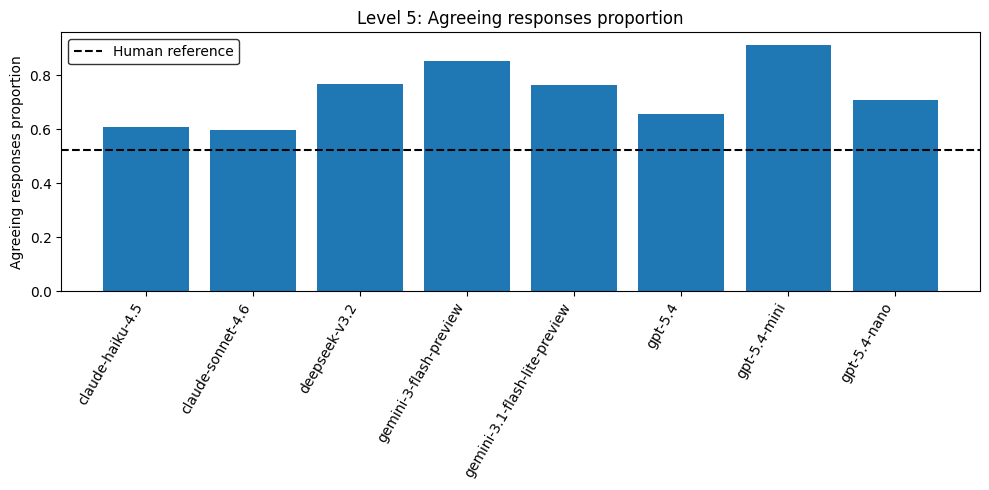

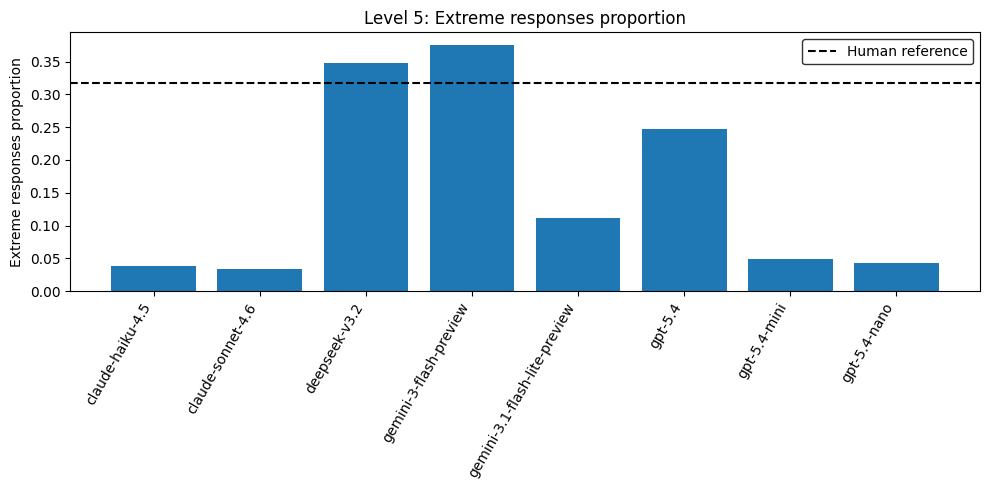

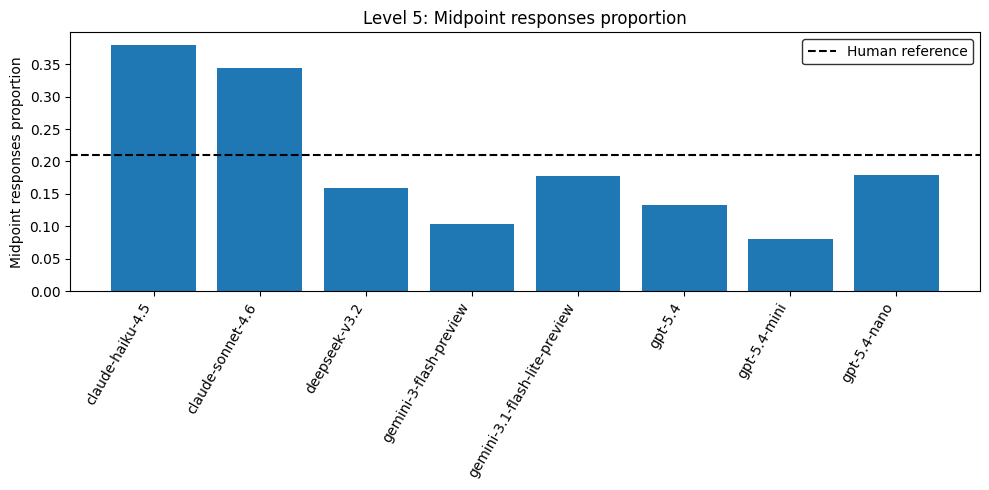

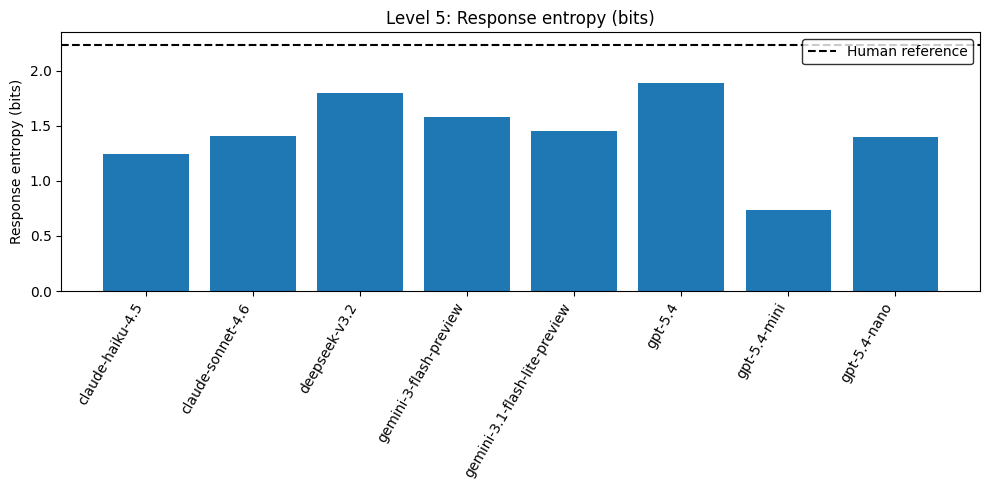

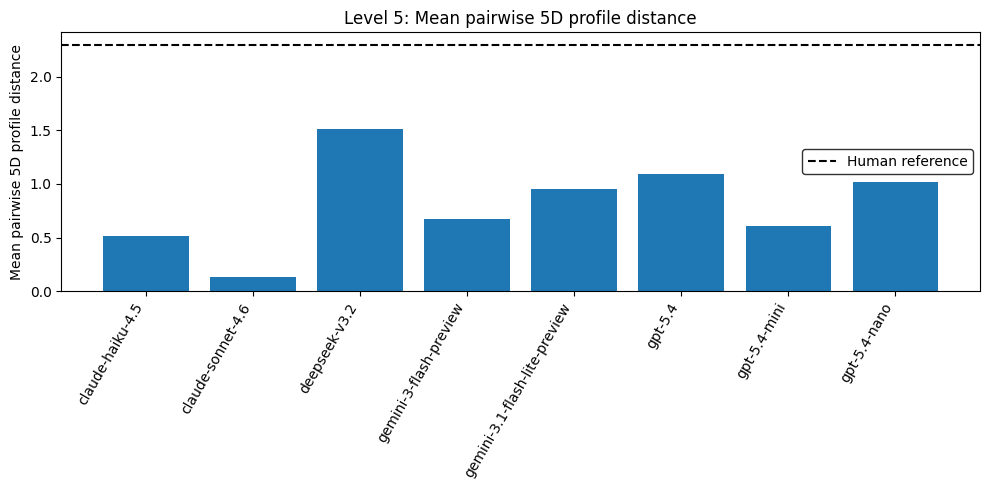

In [20]:

# Figures: response-style metrics vs humans
metrics_to_plot = [
    ("ai_agree_prop", "human_agree_prop", "Agreeing responses proportion"),
    ("ai_extreme_prop", "human_extreme_prop", "Extreme responses proportion"),
    ("ai_midpoint_prop", "human_midpoint_prop", "Midpoint responses proportion"),
    ("ai_entropy_bits", "human_entropy_bits", "Response entropy (bits)"),
    ("ai_mean_pairwise_profile_distance", "human_mean_pairwise_profile_distance", "Mean pairwise 5D profile distance"),
]

for ai_metric, human_metric, ylabel in metrics_to_plot:
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(behavior_table))
    ax.bar(x, behavior_table[ai_metric])
    ax.axhline(behavior_table[human_metric].iloc[0], linestyle="--", label="Human reference")
    ax.set_xticks(x)
    ax.set_xticklabels(behavior_table["model"], rotation=60, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Level 5: {ylabel}")
    ax.legend()
    plt.tight_layout()
    save_fig(fig, f"level5_{ai_metric}")
    plt.show()


In [21]:
# Harmonize duplicate diff columns produced by merge suffixes.
for base in ["alpha_diff_ai_minus_human", "omega_diff_ai_minus_human"]:
    x_col = f"{base}_x"
    y_col = f"{base}_y"

    if base not in rel_compare.columns:
        if x_col in rel_compare.columns:
            rel_compare[base] = rel_compare[x_col]
        elif y_col in rel_compare.columns:
            rel_compare[base] = rel_compare[y_col]

rel_compare = rel_compare.drop(
    columns=[
        "alpha_diff_ai_minus_human_x",
        "alpha_diff_ai_minus_human_y",
        "omega_diff_ai_minus_human_x",
        "omega_diff_ai_minus_human_y",
    ],
    errors="ignore",
)

save_df(rel_compare, "level3_reliability_model_vs_human")
display(rel_compare.head(15))

,group,model,trait,alpha,omega,alpha_ci_low,alpha_ci_high,omega_ci_low,omega_ci_high,human_alpha,human_omega,human_alpha_ci_low,human_alpha_ci_high,human_omega_ci_low,human_omega_ci_high,n_used_human,n_used_ai,alpha_diff_ci_low,alpha_diff_ci_high,alpha_perm_p,omega_diff_ci_low,omega_diff_ci_high,omega_perm_p,alpha_perm_p_fdr,omega_perm_p_fdr,alpha_diff_ai_minus_human,omega_diff_ai_minus_human
0,AI,claude-haiku-4.5,Agreeableness,0.680418,0.925052,0.524975,0.703408,0.895063,0.933343,0.852490,0.859966,0.848665,0.860829,0.851971,0.863911,5000,5000,-0.343681,-0.144814,0.000999,0.039129,0.077151,0.000999,0.001110,0.001052,-0.172072,0.065085
1,AI,claude-sonnet-4.6,Agreeableness,0.067990,0.647070,0.048970,0.164282,0.630804,0.740747,0.852490,0.859966,0.848665,0.860829,0.851971,0.863911,5000,5000,-0.809732,-0.690174,0.000999,-0.230388,-0.121641,0.000999,0.001110,0.001052,-0.784500,-0.212896
2,AI,deepseek-v3.2,Agreeableness,0.825225,0.832767,0.808437,0.823799,0.816741,0.833250,0.852490,0.859966,0.848665,0.860829,0.851971,0.863911,5000,5000,-0.047051,-0.026201,0.000999,-0.046102,-0.025292,0.000999,0.001110,0.001052,-0.027265,-0.027200
3,AI,gemini-3-flash-preview,Agreeableness,0.698036,0.675324,0.684728,0.708639,0.658365,0.706575,0.852490,0.859966,0.848665,0.860829,0.851971,0.863911,5000,5000,-0.169287,-0.139808,0.000999,-0.202072,-0.153475,0.000999,0.001110,0.001052,-0.154454,-0.184642
4,AI,gemini-3.1-flash-lite-preview,Agreeableness,0.879537,0.894135,0.874015,0.885264,0.887489,0.899094,0.852490,0.859966,0.848665,0.860829,0.851971,0.863911,5000,5000,0.020957,0.037918,0.000999,0.027559,0.043249,0.000999,0.001110,0.001052,0.027046,0.034169
5,AI,gpt-5.4,Agreeableness,0.554789,0.556548,0.540529,0.563874,0.521907,0.609943,0.852490,0.859966,0.848665,0.860829,0.851971,0.863911,5000,5000,-0.313014,-0.284307,0.000999,-0.328700,-0.247724,0.000999,0.001110,0.001052,-0.297702,-0.303418
6,AI,gpt-5.4-mini,Agreeableness,0.836031,0.943408,0.823918,0.864081,0.942147,0.954979,0.852490,0.859966,0.848665,0.860829,0.851971,0.863911,5000,5000,-0.032530,0.010146,0.120879,0.077706,0.094612,0.000999,0.120879,0.001052,-0.016460,0.083442
7,AI,gpt-5.4-nano,Agreeableness,0.269533,0.279561,0.224732,0.289454,0.251116,0.320700,0.852490,0.859966,0.848665,0.860829,0.851971,0.863911,5000,5000,-0.629825,-0.564463,0.000999,-0.612603,-0.537503,0.000999,0.001110,0.001052,-0.582957,-0.580405
8,AI,claude-haiku-4.5,Conscientiousness,0.913588,0.924773,0.906145,0.917892,0.917671,0.929314,0.834218,0.834418,0.828755,0.841853,0.830705,0.844306,5000,5000,0.073516,0.092687,0.000999,0.084936,0.103788,0.000999,0.001110,0.001052,0.079370,0.090355
9,AI,claude-sonnet-4.6,Conscientiousness,0.457886,NaN,0.403207,0.475939,NaN,NaN,0.834218,0.834418,0.828755,0.841853,0.830705,0.844306,5000,5000,-0.428740,-0.358594,0.000999,NaN,NaN,0.000999,0.001110,0.001052,-0.376332,NaN



# 6) Integrated summary tables

This section creates concise summary tables by level, then a combined "at-a-glance" table you can use in the paper draft.


In [22]:
# Summaries by level
level1_summary = central_table[[
    "model", "trait", "human_mean", "ai_mean", "mean_diff_human_minus_ai", "p_fdr", "hedges_g"
]].copy()

level2_summary = dist_table[[
    "model", "trait", "wasserstein", "wasserstein_perm_p_fdr", "energy_distance", "ks_p_fdr", "brown_forsythe_p_fdr"
]].copy()

level3_summary = rel_compare[[
    "model", "trait",
    "human_alpha", "alpha", "alpha_diff_ai_minus_human", "alpha_diff_ci_low", "alpha_diff_ci_high", "alpha_perm_p_fdr",
    "human_omega", "omega", "omega_diff_ai_minus_human", "omega_diff_ci_low", "omega_diff_ci_high", "omega_perm_p_fdr"
]].rename(columns={"alpha": "ai_alpha", "omega": "ai_omega"}).copy()

level4_summary = struct_table[[
    "model",
    "trait_corr_frobenius", "trait_corr_frobenius_perm_p_fdr",
    "trait_corr_matrix_r", "trait_corr_matrix_r_ci_low", "trait_corr_matrix_r_ci_high",
    "item_corr_frobenius", "item_corr_frobenius_perm_p_fdr",
    "item_corr_matrix_r", "item_corr_matrix_r_ci_low", "item_corr_matrix_r_ci_high",
    "human_variance_explained_5f", "model_variance_explained_5f",
    "mean_abs_tucker_congruence", "mean_abs_tucker_ci_low", "mean_abs_tucker_ci_high", "mean_abs_tucker_perm_p_fdr",
    "max_abs_tucker_congruence"
]].copy()

level5_summary = behavior_table[[
    "model", "cramers_v", "chi2_p_fdr", "ai_agree_prop", "ai_extreme_prop", "ai_midpoint_prop", "ai_entropy_bits", "ai_mean_pairwise_profile_distance"
]].copy()

save_df(level1_summary, "summary_level1")
save_df(level2_summary, "summary_level2")
save_df(level3_summary, "summary_level3")
save_df(level4_summary, "summary_level4")
save_df(level5_summary, "summary_level5")

display(level1_summary.head(10))
display(level2_summary.head(10))
display(level3_summary.head(10))
display(level4_summary.head(10))
display(level5_summary.head(10))

,model,trait,human_mean,ai_mean,mean_diff_human_minus_ai,p_fdr,hedges_g
0,claude-haiku-4.5,Agreeableness,3.785685,4.04422,-0.258535,0.0,-0.361519
1,claude-sonnet-4.6,Agreeableness,3.785685,4.07427,-0.288585,0.0,-0.403579
2,deepseek-v3.2,Agreeableness,3.785685,4.64003,-0.854345,0.0,-1.193184
3,gemini-3-flash-preview,Agreeableness,3.785685,4.40799,-0.622305,0.0,-0.870236
4,gemini-3.1-flash-lite-preview,Agreeableness,3.785685,4.19018,-0.404495,0.0,-0.565294
5,gpt-5.4,Agreeableness,3.785685,4.69615,-0.910465,0.0,-1.272985
6,gpt-5.4-mini,Agreeableness,3.785685,4.15025,-0.364565,0.0,-0.509604
7,gpt-5.4-nano,Agreeableness,3.785685,4.04404,-0.258355,0.0,-0.361283
8,claude-haiku-4.5,Conscientiousness,3.349079,4.01458,-0.665501,0.0,-0.915290
9,claude-sonnet-4.6,Conscientiousness,3.349079,3.54272,-0.193641,0.0,-0.266507


,model,trait,wasserstein,wasserstein_perm_p_fdr,energy_distance,ks_p_fdr,brown_forsythe_p_fdr
0,claude-haiku-4.5,Extraversion,0.67393,0.0002,0.606077,0.0,0.0
1,claude-haiku-4.5,Emotional_Stability,0.50913,0.0002,0.533993,0.0,0.0
2,claude-haiku-4.5,Agreeableness,0.54095,0.0002,0.551678,0.0,0.0
3,claude-haiku-4.5,Conscientiousness,0.77582,0.0002,0.815728,0.0,0.0
4,claude-haiku-4.5,Openness,0.45431,0.0002,0.510490,0.0,0.0
5,claude-sonnet-4.6,Extraversion,0.73249,0.0002,0.657162,0.0,0.0
6,claude-sonnet-4.6,Emotional_Stability,0.84257,0.0002,0.841679,0.0,0.0
7,claude-sonnet-4.6,Agreeableness,0.55243,0.0002,0.566087,0.0,0.0
8,claude-sonnet-4.6,Conscientiousness,0.55427,0.0002,0.571708,0.0,0.0
9,claude-sonnet-4.6,Openness,0.49080,0.0002,0.548995,0.0,0.0


,model,trait,human_alpha,ai_alpha,alpha_diff_ai_minus_human,alpha_diff_ci_low,alpha_diff_ci_high,alpha_perm_p_fdr,human_omega,ai_omega,omega_diff_ai_minus_human,omega_diff_ci_low,omega_diff_ci_high,omega_perm_p_fdr
0,claude-haiku-4.5,Agreeableness,0.852490,0.680418,-0.172072,-0.343681,-0.144814,0.001110,0.859966,0.925052,0.065085,0.039129,0.077151,0.001052
1,claude-sonnet-4.6,Agreeableness,0.852490,0.067990,-0.784500,-0.809732,-0.690174,0.001110,0.859966,0.647070,-0.212896,-0.230388,-0.121641,0.001052
2,deepseek-v3.2,Agreeableness,0.852490,0.825225,-0.027265,-0.047051,-0.026201,0.001110,0.859966,0.832767,-0.027200,-0.046102,-0.025292,0.001052
3,gemini-3-flash-preview,Agreeableness,0.852490,0.698036,-0.154454,-0.169287,-0.139808,0.001110,0.859966,0.675324,-0.184642,-0.202072,-0.153475,0.001052
4,gemini-3.1-flash-lite-preview,Agreeableness,0.852490,0.879537,0.027046,0.020957,0.037918,0.001110,0.859966,0.894135,0.034169,0.027559,0.043249,0.001052
5,gpt-5.4,Agreeableness,0.852490,0.554789,-0.297702,-0.313014,-0.284307,0.001110,0.859966,0.556548,-0.303418,-0.328700,-0.247724,0.001052
6,gpt-5.4-mini,Agreeableness,0.852490,0.836031,-0.016460,-0.032530,0.010146,0.120879,0.859966,0.943408,0.083442,0.077706,0.094612,0.001052
7,gpt-5.4-nano,Agreeableness,0.852490,0.269533,-0.582957,-0.629825,-0.564463,0.001110,0.859966,0.279561,-0.580405,-0.612603,-0.537503,0.001052
8,claude-haiku-4.5,Conscientiousness,0.834218,0.913588,0.079370,0.073516,0.092687,0.001110,0.834418,0.924773,0.090355,0.084936,0.103788,0.001052
9,claude-sonnet-4.6,Conscientiousness,0.834218,0.457886,-0.376332,-0.428740,-0.358594,0.001110,0.834418,NaN,NaN,NaN,NaN,0.001052


,model,trait_corr_frobenius,trait_corr_frobenius_perm_p_fdr,trait_corr_matrix_r,trait_corr_matrix_r_ci_low,trait_corr_matrix_r_ci_high,item_corr_frobenius,item_corr_frobenius_perm_p_fdr,item_corr_matrix_r,item_corr_matrix_r_ci_low,item_corr_matrix_r_ci_high,human_variance_explained_5f,model_variance_explained_5f,mean_abs_tucker_congruence,mean_abs_tucker_ci_low,mean_abs_tucker_ci_high,mean_abs_tucker_perm_p_fdr,max_abs_tucker_congruence
0,claude-haiku-4.5,1.365052,0.000999,-0.464200,-0.474304,-0.417690,13.259733,0.000999,0.477727,0.465013,0.502222,0.426993,0.727554,0.297858,0.289028,0.299000,1.000000,0.908351
1,claude-sonnet-4.6,0.608703,0.000999,0.203871,0.144146,0.304373,NaN,0.000999,NaN,NaN,NaN,0.426993,0.000000,NaN,NaN,NaN,0.001332,NaN
2,deepseek-v3.2,1.387951,0.000999,0.152190,0.114075,0.229188,9.113935,0.000999,0.733477,0.718254,0.738797,0.426993,0.520843,0.405396,0.398949,0.407689,0.001332,0.945455
3,gemini-3-flash-preview,0.977807,0.000999,0.274739,0.214497,0.273979,NaN,0.000999,NaN,NaN,NaN,0.426993,0.000000,NaN,NaN,NaN,0.001332,NaN
4,gemini-3.1-flash-lite-preview,1.863132,0.000999,-0.105030,-0.125186,-0.055311,NaN,0.000999,NaN,NaN,NaN,0.426993,0.000000,NaN,NaN,NaN,0.001332,NaN
5,gpt-5.4,1.150008,0.000999,-0.133005,-0.153270,-0.077677,NaN,0.000999,NaN,NaN,NaN,0.426993,0.000000,NaN,NaN,NaN,0.001332,NaN
6,gpt-5.4-mini,1.924104,0.000999,-0.376617,-0.395664,-0.342078,19.001849,0.000999,0.322536,0.303196,0.352514,0.426993,0.777854,0.331940,0.326426,0.362685,0.001332,0.938069
7,gpt-5.4-nano,0.456536,0.000999,0.113977,-0.055646,0.198603,7.347546,0.000999,0.637440,0.625059,0.638494,0.426993,0.332408,0.289588,0.256767,0.273589,1.000000,0.951609


,model,cramers_v,chi2_p_fdr,ai_agree_prop,ai_extreme_prop,ai_midpoint_prop,ai_entropy_bits,ai_mean_pairwise_profile_distance
0,claude-haiku-4.5,0.122905,0.0,0.608424,0.038376,0.380384,1.245702,0.516855
1,claude-sonnet-4.6,0.111889,0.0,0.595782,0.033068,0.344276,1.402431,0.133137
2,deepseek-v3.2,0.072185,0.0,0.766570,0.347998,0.158714,1.793613,1.510830
3,gemini-3-flash-preview,0.093507,0.0,0.853268,0.375984,0.103128,1.577362,0.669513
4,gemini-3.1-flash-lite-preview,0.110940,0.0,0.761714,0.110870,0.176914,1.449516,0.953162
5,gpt-5.4,0.057754,0.0,0.656448,0.247294,0.132724,1.886851,1.090992
6,gpt-5.4-mini,0.170484,0.0,0.912546,0.048234,0.080460,0.735915,0.608248
7,gpt-5.4-nano,0.117816,0.0,0.705778,0.042450,0.179590,1.398848,1.022774



# 7) Export everything

This cell writes:
- all CSV tables
- all PNG figures
- one Excel workbook with major result tables

Then it zips the `outputs/` folder for one-click download in Colab.


In [23]:
major_tables = {
    "level1_central": central_table,
    "level1_anova": anova_table,
    "level2_distribution": dist_table,
    "level3_reliability_compare": rel_compare,
    "level3_reliability_infer": rel_infer_table,
    "level3_item_total": itemtotal_table,
    "level3_alpha_deleted": alpha_deleted_table,
    "level4_structural": struct_table,
    "level4_structural_infer": struct_infer_table,
    "level5_behavioral": behavior_table,
}

excel_path = OUTDIR / "big5_psychometric_fidelity_results.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet, df in major_tables.items():
        df.to_excel(writer, sheet_name=sheet[:31], index=False)

import zipfile
zip_path = Path("big5_psychometric_fidelity_outputs.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in OUTDIR.rglob("*"):
        zf.write(p, p.relative_to(OUTDIR.parent))

print("Saved Excel workbook to:", excel_path)
print("Saved zip archive to:", zip_path)

Saved Excel workbook to: outputs/big5_psychometric_fidelity_results.xlsx
Saved zip archive to: big5_psychometric_fidelity_outputs.zip


# 8) Calibration baselines and diagnostics

This section integrates the two standalone post-export scripts into the full notebook:

- `calibration_and_diagnostics.py`: data provenance, human split-half calibration, item-marginal baseline, LLM metric calibration values, calibration summary, and Level 4 degeneracy diagnostics.
- `subgroup_baseline_sensitivity.py`: country/time human subgroup baselines, item-covariance Gaussian baseline, extended calibration ladder, and Spearman structural sensitivity.

The functions below reuse the scored data, helper functions, and Level 1-5 summary tables already created by this notebook.


In [ ]:
# Post-export calibration and diagnostic settings.
# These match the standalone scripts by default; lower them for quick local checks.
CALIBRATION_N = 10_000
CALIBRATION_SPLIT_REPS = 50
SUBGROUP_REPS = 20
PROFILE_DIVERSITY_MAX_N = 2_000
CALIBRATION_WASSERSTEIN_MAX_N = 5_000

CALIBRATION_RNG = np.random.default_rng(42)
SUBGROUP_RNG = np.random.default_rng(123)
TRAIT_COLS = list(TRAIT_PREFIXES.keys())


def trait_items(trait):
    prefix = TRAIT_PREFIXES[trait]
    return [f"{prefix}{i}" for i in range(1, 11)]


def ensure_min_rows(df, n, label):
    if len(df) < n:
        raise ValueError(f"{label} needs at least {n:,} rows, got {len(df):,}")


def ensure_disjoint_rows(df, n, label):
    if len(df) < 2 * n:
        raise ValueError(f"{label} needs at least {2*n:,} rows for disjoint {n:,}-vs-{n:,} samples, got {len(df):,}")


def sample_rows(df, n, rng, label="dataframe"):
    ensure_min_rows(df, n, label)
    idx = rng.choice(len(df), size=n, replace=False)
    return df.iloc[idx].reset_index(drop=True)


def shannon_entropy_from_items(df):
    counts = response_option_counts(df, ITEM_COLS)
    return float(shannon_entropy_from_counts(counts))


def cramers_v_items(ref, comp):
    contingency = pd.DataFrame({
        "ref": response_option_counts(ref, ITEM_COLS),
        "comp": response_option_counts(comp, ITEM_COLS),
    }).T
    return float(cramers_v_from_table(contingency))


def profile_diversity(df, rng, max_n=PROFILE_DIVERSITY_MAX_N):
    profiles = df[TRAIT_COLS].to_numpy(dtype=float)
    if len(profiles) > max_n:
        profiles = profiles[rng.choice(len(profiles), size=max_n, replace=False)]
    diffs = profiles[:, None, :] - profiles[None, :, :]
    distances = np.sqrt((diffs * diffs).sum(axis=2))
    return float(distances[np.triu_indices_from(distances, k=1)].mean())


def calibration_metric_bundle(ref, comp, rng, absolute_behavior_diffs=False):
    gs = []
    ws = []
    alpha_diffs = []

    for trait in TRAIT_COLS:
        cols = trait_items(trait)
        x = ref[trait].to_numpy(dtype=float)
        y = comp[trait].to_numpy(dtype=float)
        gs.append(abs(hedges_g(x, y)))

        xw = x if len(x) <= CALIBRATION_WASSERSTEIN_MAX_N else x[rng.choice(len(x), size=CALIBRATION_WASSERSTEIN_MAX_N, replace=False)]
        yw = y if len(y) <= CALIBRATION_WASSERSTEIN_MAX_N else y[rng.choice(len(y), size=CALIBRATION_WASSERSTEIN_MAX_N, replace=False)]
        ws.append(wasserstein_distance(xw, yw))

        alpha_diffs.append(abs(cronbach_alpha_manual(ref[cols]) - cronbach_alpha_manual(comp[cols])))

    ref_corr = ref[TRAIT_COLS].corr()
    comp_corr = comp[TRAIT_COLS].corr()
    trait_frob = np.sqrt(((ref_corr - comp_corr) ** 2).to_numpy().sum())

    ref_entropy = shannon_entropy_from_items(ref)
    comp_entropy = shannon_entropy_from_items(comp)
    ref_diversity = profile_diversity(ref, rng)
    comp_diversity = profile_diversity(comp, rng)

    entropy_diff = ref_entropy - comp_entropy
    diversity_diff = ref_diversity - comp_diversity
    if absolute_behavior_diffs:
        entropy_diff = abs(entropy_diff)
        diversity_diff = abs(diversity_diff)

    return {
        "mean_abs_g": float(np.nanmean(gs)),
        "mean_wasserstein": float(np.nanmean(ws)),
        "mean_abs_alpha_diff": float(np.nanmean(alpha_diffs)),
        "trait_corr_frobenius": float(trait_frob),
        "cramers_v": cramers_v_items(ref, comp),
        "entropy_deficit": float(entropy_diff),
        "profile_diversity_deficit": float(diversity_diff),
    }


def item_marginal_sample(ref, n, rng):
    sampled = pd.DataFrame(index=np.arange(n))
    for col in ITEM_COLS:
        sampled[col] = rng.choice(ref[col].to_numpy(), size=n, replace=True)
    return score_traits(sampled)


def degeneracy_diagnostics(df, label):
    mat = df[ITEM_COLS].to_numpy(dtype=float)
    cov = np.cov(mat, rowvar=False)
    eig = np.linalg.eigvalsh(cov)
    profiles = pd.DataFrame(mat, columns=ITEM_COLS)
    unique_profiles = int(profiles.drop_duplicates().shape[0])
    max_freq = int(profiles.value_counts().max())

    return {
        "group": label,
        "n": int(len(df)),
        "zero_variance_items": int((df[ITEM_COLS].var(axis=0, ddof=1) == 0).sum()),
        "unique_profiles": unique_profiles,
        "duplicate_profile_rate": float(1 - unique_profiles / len(df)),
        "max_profile_frequency_rate": float(max_freq / len(df)),
        "covariance_rank": int(np.linalg.matrix_rank(cov)),
        "min_covariance_eigenvalue": float(eig.min()),
        "median_item_variance": float(df[ITEM_COLS].var(axis=0, ddof=1).median()),
    }


def summarize_interval(values):
    values = pd.Series(values).dropna()
    return f"{values.quantile(0.025):.3f}--{values.quantile(0.975):.3f}"


def write_data_provenance_summary():
    human_after_exclude = keep_clean_humans(human_df)
    flags = [c for c in human_after_exclude.columns if c.startswith("flag_")]
    flag_counts = {
        c: int(pd.to_numeric(human_after_exclude[c], errors="coerce").fillna(False).astype(bool).sum())
        for c in flags
    }

    rows = [
        {"field": "human_file_rows", "value": len(human_df)},
        {"field": "human_rows_after_exclude_any", "value": len(human_after_exclude)},
        {"field": "human_rows_after_item_drop", "value": len(human_scored)},
        {"field": "ai_rows_after_item_drop", "value": len(ai_scored)},
    ]

    if "country" in human_after_exclude.columns:
        country_counts = human_after_exclude["country"].value_counts(dropna=False)
        for rank, (country, count) in enumerate(country_counts.head(3).items(), start=1):
            rows.append({"field": f"country_top_{rank}", "value": str(country)})
            rows.append({"field": f"country_top_{rank}_n", "value": int(count)})

    if "dateload" in human_after_exclude.columns:
        dates = pd.to_datetime(human_after_exclude["dateload"], errors="coerce")
        rows.append({"field": "dateload_min", "value": str(dates.min())})
        rows.append({"field": "dateload_max", "value": str(dates.max())})

    rows += [{"field": f"{k}_count", "value": v} for k, v in sorted(flag_counts.items())]
    out = pd.DataFrame(rows)
    save_df(out, "data_provenance_summary")
    return out


def build_llm_metric_calibration_values():
    human_entropy = behavior_table["human_entropy_bits"].iloc[0]
    human_diversity = behavior_table["human_mean_pairwise_profile_distance"].iloc[0]

    llm = (
        level1_summary.assign(mean_abs_g=level1_summary["hedges_g"].abs())
        .groupby("model", as_index=False)["mean_abs_g"].mean()
        .merge(
            level2_summary.groupby("model", as_index=False)["wasserstein"].mean()
            .rename(columns={"wasserstein": "mean_wasserstein"}),
            on="model",
        )
        .merge(
            level3_summary.assign(mean_abs_alpha_diff=level3_summary["alpha_diff_ai_minus_human"].abs())
            .groupby("model", as_index=False)["mean_abs_alpha_diff"].mean(),
            on="model",
        )
        .merge(level4_summary[["model", "trait_corr_frobenius"]], on="model")
        .merge(
            level5_summary[["model", "cramers_v", "ai_entropy_bits", "ai_mean_pairwise_profile_distance"]],
            on="model",
        )
    )
    llm["entropy_deficit"] = human_entropy - llm["ai_entropy_bits"]
    llm["profile_diversity_deficit"] = human_diversity - llm["ai_mean_pairwise_profile_distance"]
    save_df(llm, "llm_metric_calibration_values")
    return llm


def run_calibration_and_diagnostics(n=CALIBRATION_N, split_reps=CALIBRATION_SPLIT_REPS, rng=CALIBRATION_RNG):
    ensure_disjoint_rows(human_scored, n, "human split-half calibration")
    provenance = write_data_provenance_summary()

    split_rows = []
    for rep in range(split_reps):
        idx = rng.choice(len(human_scored), size=2 * n, replace=False)
        ref = human_scored.iloc[idx[:n]].reset_index(drop=True)
        comp = human_scored.iloc[idx[n:]].reset_index(drop=True)
        row = calibration_metric_bundle(ref, comp, rng)
        row["baseline"] = "human_split_half"
        row["replicate"] = rep
        split_rows.append(row)
    split = pd.DataFrame(split_rows)
    save_df(split, "human_split_half_calibration")

    marginal_rows = []
    for rep in range(split_reps):
        ref = sample_rows(human_scored, n, rng, "item-marginal reference")
        comp = item_marginal_sample(human_scored, n=n, rng=rng)
        row = calibration_metric_bundle(ref, comp, rng)
        row["baseline"] = "item_marginal_independent"
        row["replicate"] = rep
        marginal_rows.append(row)
    marginal = pd.DataFrame(marginal_rows)
    save_df(marginal, "item_marginal_baseline_calibration")

    llm = build_llm_metric_calibration_values()
    metrics = [
        ("mean_abs_g", "Mean |Hedges g|"),
        ("mean_wasserstein", "Mean Wasserstein"),
        ("mean_abs_alpha_diff", "Mean |Delta alpha|"),
        ("trait_corr_frobenius", "Trait-corr. Frobenius"),
        ("cramers_v", "Cramer's V"),
        ("entropy_deficit", "Entropy deficit"),
        ("profile_diversity_deficit", "Profile-diversity deficit"),
    ]

    summary_rows = []
    for key, label in metrics:
        summary_rows.append({
            "metric": label,
            "human_split_half_95": summarize_interval(split[key].abs()),
            "item_marginal_mean": float(marginal[key].mean()),
            "item_marginal_95": summarize_interval(marginal[key]),
            "best_llm": float(llm[key].min()),
            "llm_min": float(llm[key].min()),
            "llm_max": float(llm[key].max()),
            "best_llm_model": str(llm.loc[llm[key].idxmin(), "model"]),
        })
    calibration_summary = pd.DataFrame(summary_rows)
    save_df(calibration_summary, "calibration_summary")

    diag_rows = [degeneracy_diagnostics(sample_rows(human_scored, n, rng, "human degeneracy sample"), "human_sample")]
    for model_name, model_df in ai_scored.groupby("model"):
        diag_rows.append(degeneracy_diagnostics(model_df, model_name))
    degeneracy = pd.DataFrame(diag_rows)
    degeneracy = degeneracy.merge(
        struct_table[["model", "model_variance_explained_5f", "item_corr_matrix_r", "mean_abs_tucker_congruence"]]
        .rename(columns={"model": "group"}),
        on="group",
        how="left",
    )
    save_df(degeneracy, "level4_degeneracy_diagnostics")

    print("Wrote calibration and diagnostic outputs:")
    for name in [
        "data_provenance_summary.csv",
        "human_split_half_calibration.csv",
        "item_marginal_baseline_calibration.csv",
        "llm_metric_calibration_values.csv",
        "calibration_summary.csv",
        "level4_degeneracy_diagnostics.csv",
    ]:
        print(" -", OUTDIR / name)

    print("\nCalibration summary:")
    display(calibration_summary)
    print("\nLevel 4 degeneracy diagnostics:")
    display(degeneracy)

    return {
        "provenance": provenance,
        "human_split_half": split,
        "item_marginal": marginal,
        "llm_metric_calibration_values": llm,
        "calibration_summary": calibration_summary,
        "degeneracy": degeneracy,
    }


calibration_outputs = run_calibration_and_diagnostics()
calibration_summary = calibration_outputs["calibration_summary"]
level4_degeneracy_diagnostics = calibration_outputs["degeneracy"]


Wrote calibration and diagnostic outputs:
 - outputs/data_provenance_summary.csv
 - outputs/human_split_half_calibration.csv
 - outputs/item_marginal_baseline_calibration.csv
 - outputs/llm_metric_calibration_values.csv
 - outputs/calibration_summary.csv
 - outputs/level4_degeneracy_diagnostics.csv

Calibration summary:


,metric,human_split_half_95,item_marginal_mean,item_marginal_95,best_llm,llm_min,llm_max,best_llm_model
0,Mean |Hedges g|,0.005--0.020,0.010813,0.004--0.018,0.310993,0.310993,1.094374,claude-sonnet-4.6
1,Mean Wasserstein,0.012--0.026,0.336093,0.330--0.343,0.477456,0.477456,0.880976,gpt-5.4-nano
2,Mean |Delta alpha|,0.001--0.005,0.856450,0.845--0.871,0.032378,0.032378,0.744792,gemini-3.1-flash-lite-preview
3,Trait-corr. Frobenius,0.036--0.091,0.742009,0.697--0.776,0.456536,0.456536,1.924104,gpt-5.4-nano
4,Cramer's V,0.001--0.006,0.002921,0.001--0.005,0.057754,0.057754,0.170484,gpt-5.4
5,Entropy deficit,0.000--0.005,0.000038,-0.003--0.003,0.348295,0.348295,1.499232,gpt-5.4
6,Profile-diversity deficit,0.001--0.039,1.215680,1.188--1.252,0.790567,0.790567,2.168260,deepseek-v3.2



Level 4 degeneracy diagnostics:


,group,n,zero_variance_items,unique_profiles,duplicate_profile_rate,max_profile_frequency_rate,covariance_rank,min_covariance_eigenvalue,median_item_variance,model_variance_explained_5f,item_corr_matrix_r,mean_abs_tucker_congruence
0,human_sample,10000,0,10000,0.0000,0.0001,50,2.841461e-01,1.344019,NaN,NaN,NaN
1,claude-haiku-4.5,10000,0,1057,0.8943,0.1458,49,-2.320271e-17,0.056801,0.727554,0.477727,0.297858
2,claude-sonnet-4.6,10000,28,90,0.9910,0.3755,19,-7.457276e-16,0.000000,0.000000,NaN,NaN
3,deepseek-v3.2,10000,0,9997,0.0003,0.0003,50,2.969195e-02,0.334187,0.520843,0.733477,0.405396
4,gemini-3-flash-preview,10000,3,1337,0.8663,0.0899,46,-2.344727e-16,0.037667,0.000000,NaN,NaN
5,gemini-3.1-flash-lite-preview,10000,1,3471,0.6529,0.0340,49,-7.245674e-18,0.111513,0.000000,NaN,NaN
6,gpt-5.4,10000,1,4225,0.5775,0.0412,48,-2.027180e-17,0.165494,0.000000,NaN,NaN
7,gpt-5.4-mini,10000,0,2112,0.7888,0.1999,46,-1.436597e-17,0.065090,0.777854,0.322536,0.331940
8,gpt-5.4-nano,10000,0,9729,0.0271,0.0007,50,4.034154e-04,0.157337,0.332408,0.637440,0.289588


In [25]:
def item_covariance_gaussian(ref_source, n, rng):
    x = ref_source[ITEM_COLS].to_numpy(dtype=float)
    mean = x.mean(axis=0)
    cov = np.cov(x, rowvar=False)
    cov = cov + np.eye(cov.shape[0]) * 1e-6
    sampled = rng.multivariate_normal(mean, cov, size=n, check_valid="ignore")
    sampled = np.rint(np.clip(sampled, LIKERT_MIN, LIKERT_MAX)).astype(int)
    return score_traits(pd.DataFrame(sampled, columns=ITEM_COLS))


def upper_triangle_corr(a, b):
    av = a.to_numpy()[np.triu_indices_from(a, k=1)]
    bv = b.to_numpy()[np.triu_indices_from(b, k=1)]
    mask = np.isfinite(av) & np.isfinite(bv)
    if mask.sum() < 2 or np.std(av[mask]) == 0 or np.std(bv[mask]) == 0:
        return np.nan
    return float(np.corrcoef(av[mask], bv[mask])[0, 1])


def correlation_sensitivity(human_ref_source, ai_ref_source, n=CALIBRATION_N, rng=SUBGROUP_RNG):
    human_ref = sample_rows(human_ref_source, n, rng, "Spearman sensitivity human reference")
    rows = []

    human_trait_pearson = human_ref[TRAIT_COLS].corr(method="pearson")
    human_trait_spearman = human_ref[TRAIT_COLS].corr(method="spearman")
    human_item_pearson = human_ref[ITEM_COLS].corr(method="pearson")
    human_item_spearman = human_ref[ITEM_COLS].corr(method="spearman")

    for model_name, model_df in ai_ref_source.groupby("model"):
        model_df = model_df.reset_index(drop=True)
        trait_pearson = model_df[TRAIT_COLS].corr(method="pearson")
        trait_spearman = model_df[TRAIT_COLS].corr(method="spearman")
        item_pearson = model_df[ITEM_COLS].corr(method="pearson")
        item_spearman = model_df[ITEM_COLS].corr(method="spearman")
        spearman_item_vec = item_spearman.to_numpy()[np.triu_indices_from(item_spearman, k=1)]

        rows.append({
            "model": model_name,
            "trait_frobenius_pearson": float(np.sqrt(((human_trait_pearson - trait_pearson) ** 2).to_numpy().sum())),
            "trait_frobenius_spearman": float(np.sqrt(((human_trait_spearman - trait_spearman) ** 2).to_numpy().sum())),
            "trait_upper_r_pearson": upper_triangle_corr(human_trait_pearson, trait_pearson),
            "trait_upper_r_spearman": upper_triangle_corr(human_trait_spearman, trait_spearman),
            "item_upper_r_pearson": upper_triangle_corr(human_item_pearson, item_pearson),
            "item_upper_r_spearman": upper_triangle_corr(human_item_spearman, item_spearman),
            "spearman_item_valid_pair_fraction": float(np.isfinite(spearman_item_vec).mean()),
        })

    return pd.DataFrame(rows)


def subgroup_metric_bundle(ref, comp, rng):
    row = calibration_metric_bundle(ref, comp, rng, absolute_behavior_diffs=True)
    row["entropy_abs_diff"] = row.pop("entropy_deficit")
    row["profile_diversity_abs_diff"] = row.pop("profile_diversity_deficit")
    return row


def summarize_mean_range(df, metric):
    means = df.groupby("comparison")[metric].mean()
    return f"{means.min():.3f}--{means.max():.3f}"


def run_subgroup_baseline_sensitivity(n=CALIBRATION_N, subgroup_reps=SUBGROUP_REPS, rng=SUBGROUP_RNG):
    if "country" not in human_scored.columns:
        raise ValueError("human_scored must include a country column for subgroup calibration")
    if "dateload" not in human_scored.columns:
        raise ValueError("human_scored must include a dateload column for temporal subgroup calibration")

    human_meta = human_scored.copy()
    human_meta["dateload"] = pd.to_datetime(human_meta["dateload"], errors="coerce")

    country_groups = {
        c: human_meta.loc[human_meta["country"] == c].reset_index(drop=True)
        for c in ["US", "GB", "CA"]
    }
    for country, group in country_groups.items():
        ensure_min_rows(group, n, f"country subgroup {country}")
    ensure_disjoint_rows(country_groups["US"], n, "US-vs-US subgroup calibration")

    median_date = human_meta["dateload"].dropna().median()
    early = human_meta.loc[human_meta["dateload"] <= median_date].reset_index(drop=True)
    late = human_meta.loc[human_meta["dateload"] > median_date].reset_index(drop=True)
    ensure_min_rows(early, n, "early temporal subgroup")
    ensure_min_rows(late, n, "late temporal subgroup")

    comparisons = [
        ("US-vs-US", country_groups["US"], country_groups["US"], True),
        ("US-vs-GB", country_groups["US"], country_groups["GB"], False),
        ("US-vs-CA", country_groups["US"], country_groups["CA"], False),
        ("GB-vs-CA", country_groups["GB"], country_groups["CA"], False),
        ("early-vs-late", early, late, False),
    ]

    subgroup_rows = []
    for name, a, b, disjoint_same in comparisons:
        for rep in range(subgroup_reps):
            if disjoint_same:
                idx = rng.choice(len(a), size=2 * n, replace=False)
                ref = a.iloc[idx[:n]].reset_index(drop=True)
                comp = a.iloc[idx[n:]].reset_index(drop=True)
            else:
                ref = sample_rows(a, n, rng, f"{name} reference")
                comp = sample_rows(b, n, rng, f"{name} comparison")
            row = subgroup_metric_bundle(ref, comp, rng)
            row["comparison"] = name
            row["replicate"] = rep
            subgroup_rows.append(row)
    subgroup = pd.DataFrame(subgroup_rows)
    save_df(subgroup, "human_subgroup_calibration")

    covariance_rows = []
    for rep in range(subgroup_reps):
        ref = sample_rows(human_meta, n, rng, "item-covariance Gaussian reference")
        comp = item_covariance_gaussian(human_meta, n, rng)
        row = subgroup_metric_bundle(ref, comp, rng)
        row["baseline"] = "item_covariance_gaussian"
        row["replicate"] = rep
        covariance_rows.append(row)
    item_covariance = pd.DataFrame(covariance_rows)
    save_df(item_covariance, "item_covariance_gaussian_baseline")

    key_map = {
        "Mean |Hedges g|": "mean_abs_g",
        "Mean Wasserstein": "mean_wasserstein",
        "Mean |Delta alpha|": "mean_abs_alpha_diff",
        "Trait-corr. Frobenius": "trait_corr_frobenius",
        "Cramer's V": "cramers_v",
        "Entropy deficit": "entropy_abs_diff",
        "Profile-diversity deficit": "profile_diversity_abs_diff",
    }

    ladder_rows = []
    for _, row in calibration_summary.iterrows():
        metric = row["metric"]
        key = key_map[metric]
        ladder_rows.append({
            "metric": metric,
            "human_split_half_95": row["human_split_half_95"],
            "human_subgroup_mean_range": summarize_mean_range(subgroup, key),
            "item_marginal_mean": row["item_marginal_mean"],
            "item_cov_gaussian_mean": item_covariance[key].mean(),
            "best_llm": row["best_llm"],
            "llm_min": row["llm_min"],
            "llm_max": row["llm_max"],
        })
    extended_ladder = pd.DataFrame(ladder_rows)
    save_df(extended_ladder, "extended_baseline_ladder")

    spearman_sensitivity = correlation_sensitivity(human_meta, ai_scored, n=n, rng=rng)
    save_df(spearman_sensitivity, "spearman_structural_sensitivity")

    print("Subgroup calibration means:")
    display(subgroup.groupby("comparison")[list(key_map.values())].mean())
    print("\nItem-covariance Gaussian baseline means:")
    display(item_covariance[list(key_map.values())].mean().to_frame("mean"))
    print("\nExtended baseline ladder:")
    display(extended_ladder)
    print("\nSpearman structural sensitivity:")
    display(spearman_sensitivity)

    return {
        "human_subgroup": subgroup,
        "item_covariance_gaussian": item_covariance,
        "extended_baseline_ladder": extended_ladder,
        "spearman_structural_sensitivity": spearman_sensitivity,
    }


def refresh_full_exports(extra_outputs):
    full_tables = dict(major_tables)
    full_tables.update({
        "calibration_summary": calibration_summary,
        "data_provenance": calibration_outputs["provenance"],
        "human_split_half_cal": calibration_outputs["human_split_half"],
        "item_marginal_cal": calibration_outputs["item_marginal"],
        "llm_metric_calibration": calibration_outputs["llm_metric_calibration_values"],
        "level4_degeneracy": calibration_outputs["degeneracy"],
        "human_subgroup_cal": extra_outputs["human_subgroup"],
        "item_cov_gaussian": extra_outputs["item_covariance_gaussian"],
        "extended_ladder": extra_outputs["extended_baseline_ladder"],
        "spearman_sensitivity": extra_outputs["spearman_structural_sensitivity"],
    })

    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
        for sheet, df in full_tables.items():
            df.to_excel(writer, sheet_name=sheet[:31], index=False)

    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
        for p in OUTDIR.rglob("*"):
            zf.write(p, p.relative_to(OUTDIR.parent))

    print("Refreshed Excel workbook with calibration sheets:", excel_path)
    print("Refreshed zip archive with post-export outputs:", zip_path)


subgroup_outputs = run_subgroup_baseline_sensitivity()
extended_baseline_ladder = subgroup_outputs["extended_baseline_ladder"]
spearman_structural_sensitivity = subgroup_outputs["spearman_structural_sensitivity"]
refresh_full_exports(subgroup_outputs)


Subgroup calibration means:


,mean_abs_g,mean_wasserstein,mean_abs_alpha_diff,trait_corr_frobenius,cramers_v,entropy_abs_diff,profile_diversity_abs_diff
comparison,,,,,,,
GB-vs-CA,0.088341,0.073194,0.005913,0.088729,0.025824,0.013123,0.022969
US-vs-CA,0.046527,0.039672,0.004112,0.097620,0.017457,0.004537,0.021047
US-vs-GB,0.125284,0.103979,0.006338,0.142685,0.041993,0.017127,0.015248
US-vs-US,0.010178,0.018967,0.002248,0.062878,0.003562,0.001800,0.022610
early-vs-late,0.062586,0.051129,0.006840,0.159554,0.028985,0.008090,0.042993



Item-covariance Gaussian baseline means:


,mean
mean_abs_g,0.055129
mean_wasserstein,0.082144
mean_abs_alpha_diff,0.020538
trait_corr_frobenius,0.065333
cramers_v,0.093154
entropy_abs_diff,0.042688
profile_diversity_abs_diff,0.234045



Extended baseline ladder:


,metric,human_split_half_95,human_subgroup_mean_range,item_marginal_mean,item_cov_gaussian_mean,best_llm,llm_min,llm_max
0,Mean |Hedges g|,0.005--0.020,0.010--0.125,0.010813,0.055129,0.310993,0.310993,1.094374
1,Mean Wasserstein,0.012--0.026,0.019--0.104,0.336093,0.082144,0.477456,0.477456,0.880976
2,Mean |Delta alpha|,0.001--0.005,0.002--0.007,0.856450,0.020538,0.032378,0.032378,0.744792
3,Trait-corr. Frobenius,0.036--0.091,0.063--0.160,0.742009,0.065333,0.456536,0.456536,1.924104
4,Cramer's V,0.001--0.006,0.004--0.042,0.002921,0.093154,0.057754,0.057754,0.170484
5,Entropy deficit,0.000--0.005,0.002--0.017,0.000038,0.042688,0.348295,0.348295,1.499232
6,Profile-diversity deficit,0.001--0.039,0.015--0.043,1.215680,0.234045,0.790567,0.790567,2.168260



Spearman structural sensitivity:


,model,trait_frobenius_pearson,trait_frobenius_spearman,trait_upper_r_pearson,trait_upper_r_spearman,item_upper_r_pearson,item_upper_r_spearman,spearman_item_valid_pair_fraction
0,claude-haiku-4.5,1.378226,0.756412,-0.505080,0.217782,0.467936,0.481620,1.000000
1,claude-sonnet-4.6,0.616016,0.752612,0.191811,0.019369,0.475291,0.477259,0.188571
2,deepseek-v3.2,1.390275,1.426691,0.108781,0.072944,0.734383,0.732517,1.000000
3,gemini-3-flash-preview,0.956762,0.939095,0.326510,0.371680,0.591072,0.584587,0.882449
4,gemini-3.1-flash-lite-preview,1.860155,1.648343,-0.108511,0.449584,0.492436,0.489966,0.960000
5,gpt-5.4,1.155936,1.110832,-0.164415,0.203370,0.625961,0.622810,0.960000
6,gpt-5.4-mini,1.927339,1.114447,-0.404877,-0.130587,0.314479,0.285809,1.000000
7,gpt-5.4-nano,0.469735,0.487214,0.082032,0.001869,0.641547,0.634082,1.000000


Refreshed Excel workbook with calibration sheets: outputs/big5_psychometric_fidelity_results.xlsx
Refreshed zip archive with post-export outputs: big5_psychometric_fidelity_outputs.zip


# 9) Notes for interpretation

## Level 1 - Central tendency fidelity
Use this to answer:
- Which models match human average scores?
- Which traits are systematically shifted up or down?

## Level 2 - Distribution fidelity
Use this to answer:
- Do models match the *shape* of human trait distributions?
- Can a model match the mean while still differing in spread, skew, or tails?

## Level 3 - Reliability fidelity
Use this to answer:
- Do model responses cohere psychometrically like human responses?
- Are some traits internally consistent for humans but not for models?

## Level 4 - Structural fidelity
Use this to answer:
- Do models preserve the same correlational and latent structure?
- Does "high Agreeableness" in a model mean the same thing psychometrically as it does in humans?

## Level 5 - Behavioral fidelity
Use this to answer:
- Do models answer like human respondents?
- Are there signs of agreement bias, compressed variability, low entropy, or unnatural profile similarity?

## Added calibration and diagnostic sections
The `calibration_and_diagnostics.py` integration turns the Level 1-5 results into calibrated effect-size context. It writes the data provenance table, human split-half calibration ranges, an item-marginal independent baseline, per-model LLM calibration values, the compact calibration summary, and Level 4 degeneracy diagnostics such as zero-variance items, duplicate response profiles, covariance rank, and item/factor structure quality.

The `subgroup_baseline_sensitivity.py` integration adds stronger interpretation anchors. It compares balanced human subgroups by country and time, adds a simple item-covariance Gaussian generator, builds the extended baseline ladder used in the paper, and checks whether Level 4 structural conclusions are similar under Spearman rather than Pearson correlations. These outputs are not a sixth audit level; they explain whether observed model-human gaps are small relative to human-human variation and whether simple non-LLM generators already recover the same summaries.

---

## Practical note about runtime
The most expensive steps are the **Level 2 permutation testing** and the post-export calibration baselines.

If the notebook runs slowly:
- lower `N_PERM` to 500 for quick exploration
- keep `N_PER_GROUP_FOR_DIST_TESTS` at 5000 or lower
- lower `CALIBRATION_SPLIT_REPS` and `SUBGROUP_REPS` for quick checks
- then rerun with stronger settings for final tables

## Practical note about reverse coding
This notebook infers reverse-coded items from the human data by default.
If you have the questionnaire's official key, edit `MANUAL_REVERSE_KEY` near the top and rerun.
